# Project 5B: Flow Matching from Scratch!

## Setup environment

In [ ]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.8 MB/s eta 0:00:00


In [ ]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
from torch import nn
import numpy as np
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm
import torch

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [ ]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv_transpose = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_transpose(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.avg_pool = nn.AvgPool2d(kernel_size=7)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.avg_pool(x)
        x = self.gelu(x)
        return x


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        self.conv_transpose = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=7, padding=0)
        self.bn = nn.BatchNorm2d(in_channels)
        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_transpose(x)
        x = self.bn(x)
        x = self.gelu(x)
        return x


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv1 = Conv(in_channels, out_channels)
        self.conv2 = Conv(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.down_conv = DownConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.down_conv(x)
        x = self.conv_block(x)
        return x


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up_conv = UpConv(in_channels, out_channels)
        self.conv_block = ConvBlock(out_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.up_conv(x)
        x = self.conv_block(x)
        return x


## Implementing Unconditional UNet

In [ ]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()

        # Encoder path
        self.conv_block_in = ConvBlock(in_channels, num_hiddens)
        self.down_block1 = DownBlock(num_hiddens, num_hiddens)
        self.down_block2 = DownBlock(num_hiddens, 2 * num_hiddens)

        # Bottleneck
        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * num_hiddens)

        # Decoder path
        self.up_block1 = UpBlock(4 * num_hiddens, num_hiddens)
        self.up_block2 = UpBlock(2 * num_hiddens, num_hiddens)

        self.conv_block_out = ConvBlock(2 * num_hiddens, num_hiddens)

        # Final output layer (just Conv2d, no BN/GELU)
        self.final_conv = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, stride=1, padding=1)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # Encoder path with skip connections
        x1 = self.conv_block_in(x)
        x2 = self.down_block1(x1)
        x3 = self.down_block2(x2)

        # Bottleneck
        x4 = self.flatten(x3)
        x5 = self.unflatten(x4)

        # Decoder path with skip connections
        x6 = torch.cat([x5, x3], dim=1)
        x7 = self.up_block1(x6)

        x8 = torch.cat([x7, x2], dim=1)
        x9 = self.up_block2(x8)

        x10 = torch.cat([x9, x1], dim=1)
        x11 = self.conv_block_out(x10)

        # Final output
        out = self.final_conv(x11)
        return out


# Part 1.2: Using the UNet to Train a Denoiser

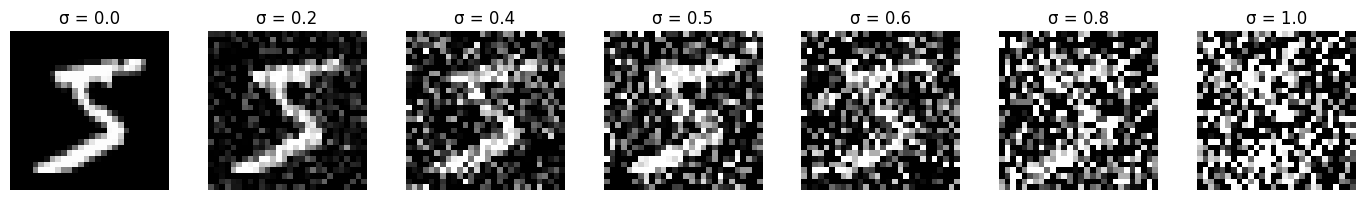

In [ ]:
# Visualize images at different noisy level
import torch
import numpy as np
import os
from PIL import Image

# Create directory to save images
os.makedirs('noisy_images', exist_ok=True)

# Load a sample MNIST image
mnist_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
sample_image, _ = mnist_dataset[0]  # Get first image
# sample_image is already normalized to [0, 1] by ToTensor()

# Define sigma values
sigma_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

# Create figure for visualization
fig, axes = plt.subplots(1, len(sigma_values), figsize=(14, 2))

# Apply noising process for each sigma
for idx, sigma in enumerate(sigma_values):
    # Generate noise: epsilon ~ N(0, I)
    epsilon = torch.randn_like(sample_image)

    # Apply noising: z = x + sigma * epsilon
    noisy_image = sample_image + sigma * epsilon

    # Clamp values to [0, 1] to ensure valid image range
    noisy_image = torch.clamp(noisy_image, 0, 1)

    # Convert to numpy for visualization
    img_np = noisy_image.squeeze().numpy()

    # Display image
    axes[idx].imshow(img_np, cmap='gray')
    axes[idx].set_title(f'σ = {sigma}')
    axes[idx].axis('off')

    # Save individual image
    img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    img_pil.save(f'noisy_images/sigma_{sigma:.1f}.png')

# Save the combined visualization
plt.tight_layout()
plt.savefig('noisy_images/noisy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [ ]:
device = torch.device('cuda')

# Set your hyperparameters

batch_size = 256
learning_rate = 1e-4
noise_level = 0.5  # sigma = 0.5
hidden_dim = 128  # D = 128
num_epochs = 5


In [ ]:
# Define your datasets and dataloaders

train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Define your model, optimizer, and loss

model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()


100%|██████████| 235/235 [01:31<00:00,  2.58it/s]


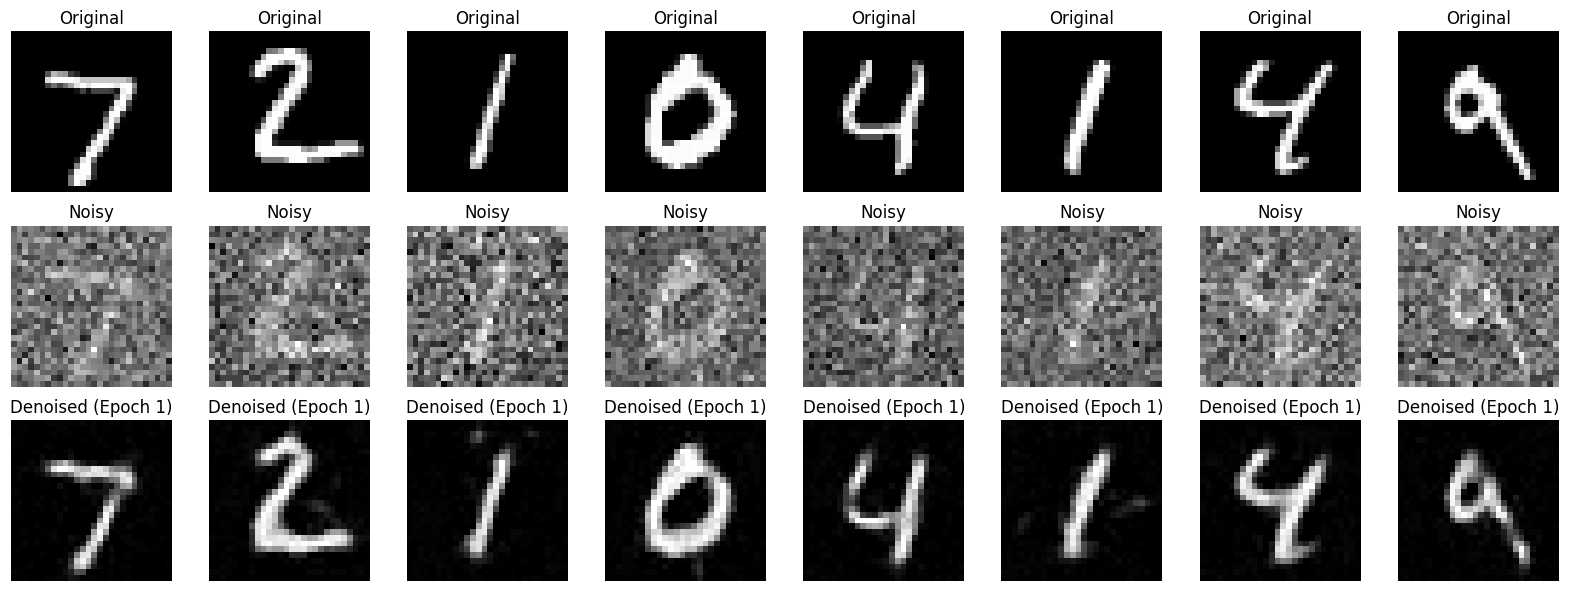

100%|██████████| 235/235 [01:40<00:00,  2.35it/s]


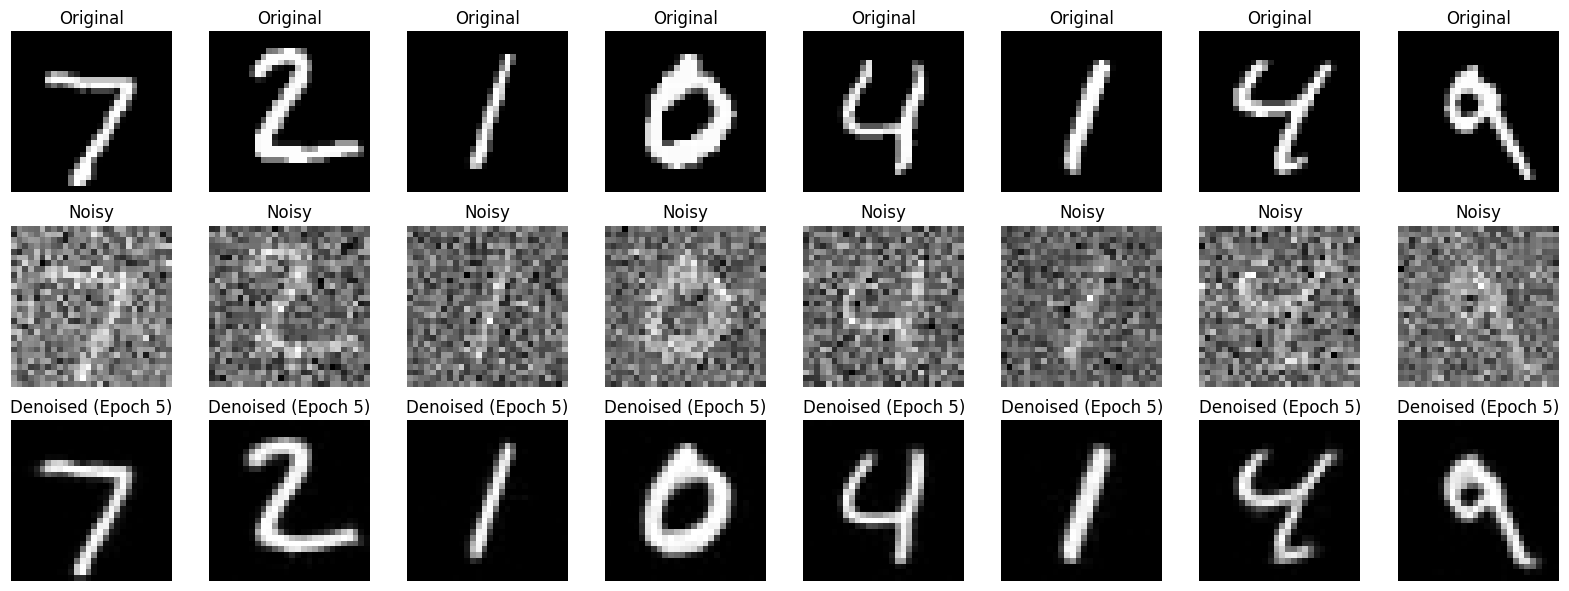

In [ ]:
# The training loops
train_losses = []
model.train()

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):


        # Move images to device
        images = images.to(device)

        # Add noise to images: z = x + sigma * epsilon, where epsilon ~ N(0, I)
        epsilon = torch.randn_like(images)
        noisy_images = images + noise_level * epsilon

        # Model predicts denoised image from noisy image
        outputs = model(noisy_images)


        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Visualize denoised results on test set after 1st and 5th epoch
    if epoch == 0 or epoch == num_epochs - 1:
        model.eval()
        with torch.no_grad():
            # Get a batch of test images
            test_images, _ = next(iter(test_loader))
            test_images = test_images.to(device)

            # Add noise
            epsilon = torch.randn_like(test_images)
            noisy_test = test_images + noise_level * epsilon

            # Denoise
            denoised = model(noisy_test)
            # Clamp denoised output to [0, 1] for visualization
            denoised = torch.clamp(denoised, 0, 1)

            # Visualize results
            fig, axes = plt.subplots(3, 8, figsize=(16, 6))
            for idx in range(8):
                # Original
                axes[0, idx].imshow(test_images[idx].cpu().squeeze(), cmap='gray')
                axes[0, idx].set_title('Original')
                axes[0, idx].axis('off')

                # Noisy
                axes[1, idx].imshow(noisy_test[idx].cpu().squeeze(), cmap='gray')
                axes[1, idx].set_title('Noisy')
                axes[1, idx].axis('off')

                # Denoised
                axes[2, idx].imshow(denoised[idx].cpu().squeeze(), cmap='gray')
                axes[2, idx].set_title(f'Denoised (Epoch {epoch+1})')
                axes[2, idx].axis('off')

            plt.tight_layout()
            plt.savefig(f'denoising_results_epoch_{epoch+1}.png', dpi=150, bbox_inches='tight')
            plt.show()

        model.train()

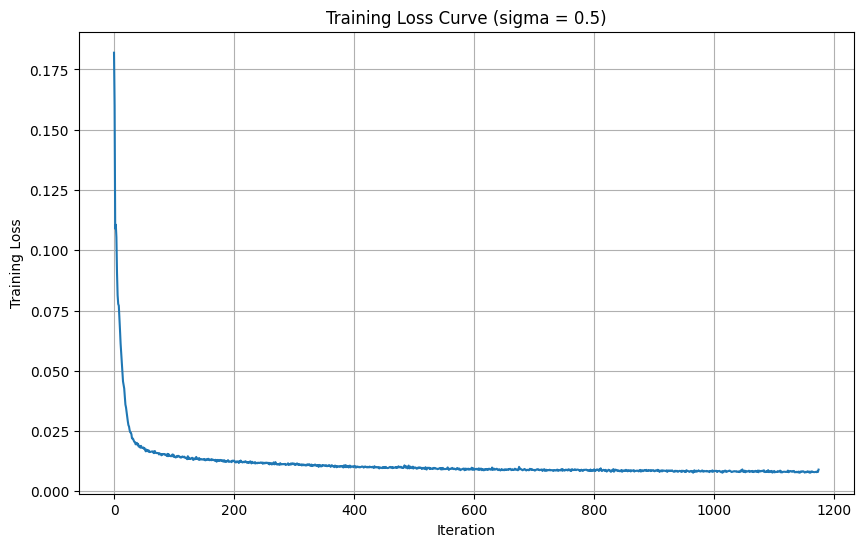

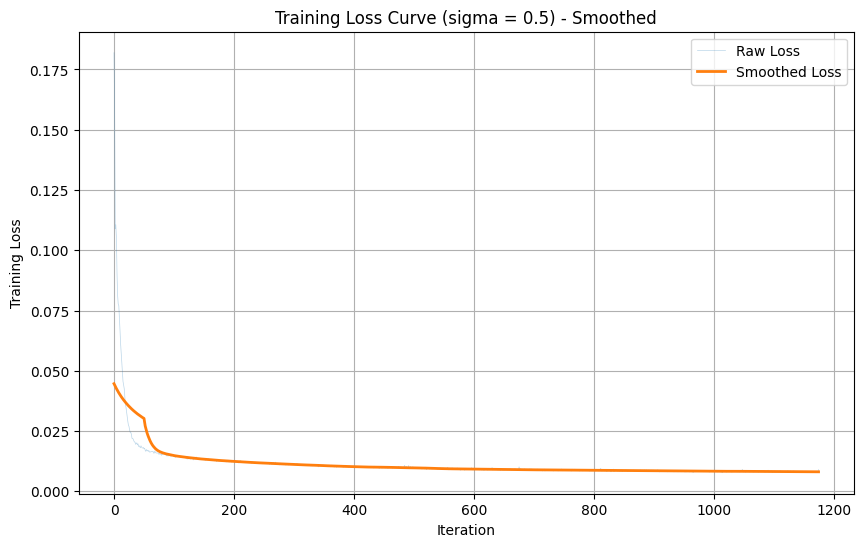

In [ ]:
# Visualize your training curve

plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title(f'Training Loss Curve (sigma = {noise_level})')
plt.grid(True)
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Also plot smoothed version (moving average)
window_size = 100
if len(train_losses) > window_size:
    smoothed_losses = []
    for i in range(len(train_losses)):
        start_idx = max(0, i - window_size // 2)
        end_idx = min(len(train_losses), i + window_size // 2)
        smoothed_losses.append(np.mean(train_losses[start_idx:end_idx]))

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, alpha=0.3, label='Raw Loss', linewidth=0.5)
    plt.plot(smoothed_losses, label='Smoothed Loss', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Training Loss')
    plt.title(f'Training Loss Curve (sigma = {noise_level}) - Smoothed')
    plt.legend()
    plt.grid(True)
    plt.savefig('training_loss_curve_smoothed.png', dpi=150, bbox_inches='tight')
    plt.show()


## Part 1.2.2: Out-of-Distribution Testing

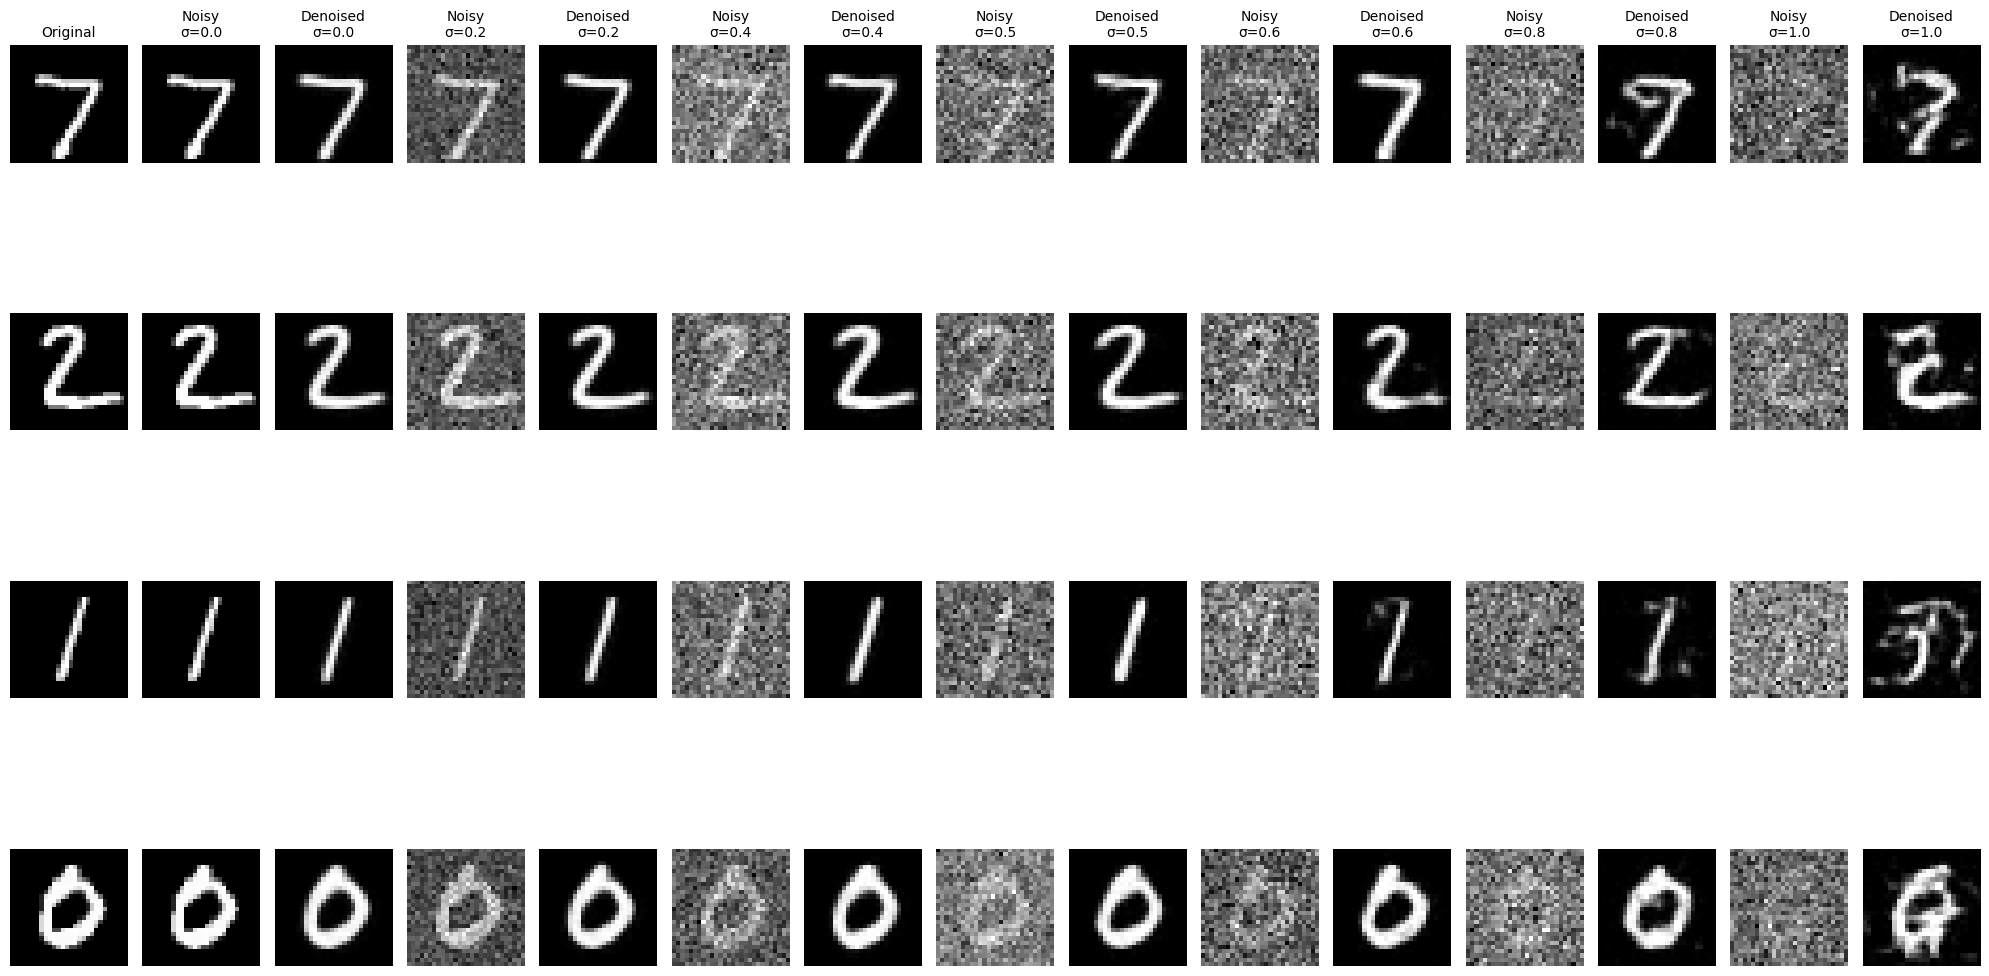

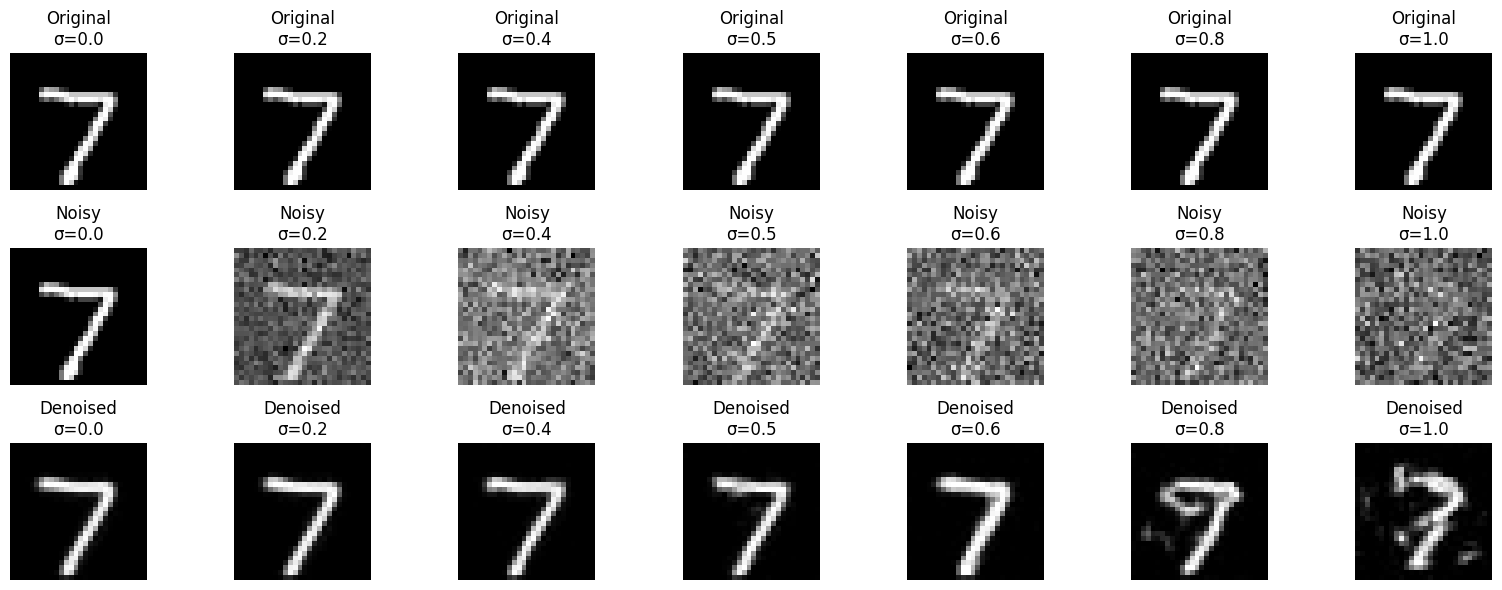

UnconditionalUNet(
  (conv_block_in): ConvBlock(
    (conv1): Conv(
      (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (gelu): GELU(approximate='none')
    )
    (conv2): Conv(
      (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (gelu): GELU(approximate='none')
    )
  )
  (down_block1): DownBlock(
    (down_conv): DownConv(
      (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (gelu): GELU(approximate='none')
    )
    (conv_block): ConvBlock(
      (conv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine

In [ ]:
# Visualize OOD testing

# Test the denoiser on different noise levels (OOD testing)
model.eval()

# Get a batch of test images (same images for all noise levels)
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

# Select a few images to visualize (e.g., 4 images)
num_samples = 4
sample_images = test_images[:num_samples]

# Noise levels to test
sigma_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

# Store results for each sigma
results = {}

with torch.no_grad():
    for sigma in sigma_values:
        # Add noise with this sigma level
        epsilon = torch.randn_like(sample_images)
        noisy_images = sample_images + sigma * epsilon

        # Denoise
        denoised = model(noisy_images)
        denoised = torch.clamp(denoised, 0, 1)

        results[sigma] = {
            'noisy': noisy_images.cpu(),
            'denoised': denoised.cpu()
        }

# Visualize results
# Create a grid: rows = images, columns = [original, noisy (for each sigma), denoised (for each sigma)]
fig, axes = plt.subplots(num_samples, 1 + 2 * len(sigma_values), figsize=(20, 3 * num_samples))

for img_idx in range(num_samples):
    col_idx = 0

    # Original image
    axes[img_idx, col_idx].imshow(sample_images[img_idx].cpu().squeeze(), cmap='gray')
    if img_idx == 0:
        axes[img_idx, col_idx].set_title('Original', fontsize=10)
    axes[img_idx, col_idx].axis('off')
    col_idx += 1

    # For each sigma: show noisy and denoised
    for sigma in sigma_values:
        # Noisy image
        axes[img_idx, col_idx].imshow(results[sigma]['noisy'][img_idx].squeeze(), cmap='gray')
        if img_idx == 0:
            axes[img_idx, col_idx].set_title(f'Noisy\nσ={sigma}', fontsize=10)
        axes[img_idx, col_idx].axis('off')
        col_idx += 1

        # Denoised image
        axes[img_idx, col_idx].imshow(results[sigma]['denoised'][img_idx].squeeze(), cmap='gray')
        if img_idx == 0:
            axes[img_idx, col_idx].set_title(f'Denoised\nσ={sigma}', fontsize=10)
        axes[img_idx, col_idx].axis('off')
        col_idx += 1

plt.tight_layout()
plt.savefig('ood_testing_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Alternative visualization: Show one image across all noise levels
# This makes it easier to see how the same image performs at different noise levels
fig, axes = plt.subplots(3, len(sigma_values), figsize=(16, 6))

for idx, sigma in enumerate(sigma_values):
    # Original (same for all)
    axes[0, idx].imshow(sample_images[0].cpu().squeeze(), cmap='gray')
    axes[0, idx].set_title(f'Original\nσ={sigma}')
    axes[0, idx].axis('off')

    # Noisy
    axes[1, idx].imshow(results[sigma]['noisy'][0].squeeze(), cmap='gray')
    axes[1, idx].set_title(f'Noisy\nσ={sigma}')
    axes[1, idx].axis('off')

    # Denoised
    axes[2, idx].imshow(results[sigma]['denoised'][0].squeeze(), cmap='gray')
    axes[2, idx].set_title(f'Denoised\nσ={sigma}')
    axes[2, idx].axis('off')

plt.tight_layout()
plt.savefig('ood_testing_single_image.png', dpi=150, bbox_inches='tight')
plt.show()

model.train()


## Part 1.2.3 Denoising Pure Noise

Mounted at /content/drive


Epoch 1/5: 100%|██████████| 235/235 [01:40<00:00,  2.33it/s]


Epoch 1/5, Average Loss: 0.074494
Checkpoint saved to /content/drive/MyDrive/denoising_pure_noise_checkpoints/checkpoint_epoch_1.pth


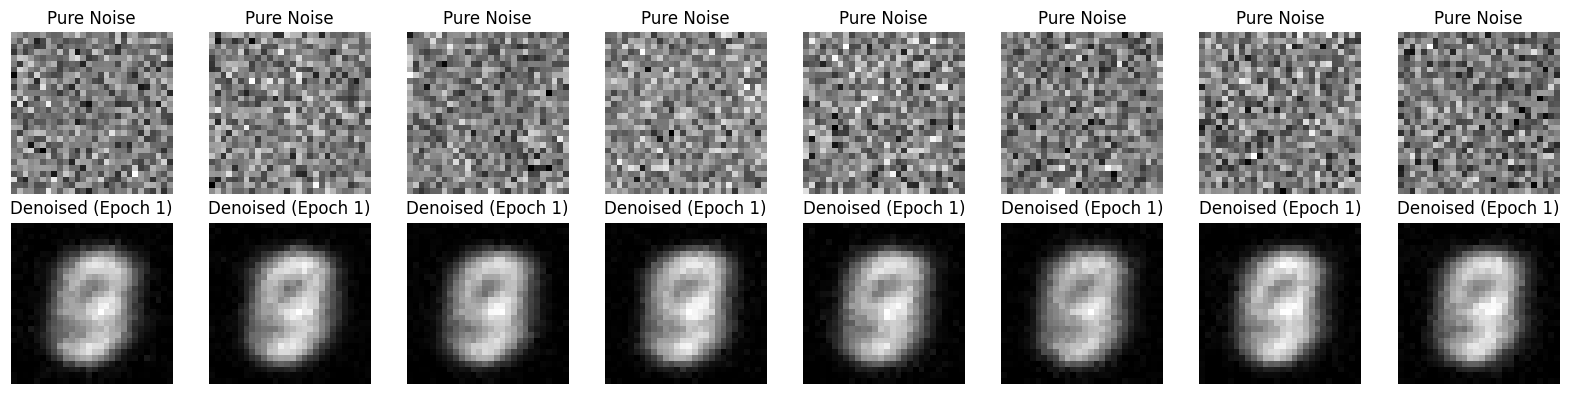

Epoch 2/5: 100%|██████████| 235/235 [01:40<00:00,  2.35it/s]


Epoch 2/5, Average Loss: 0.067547
Checkpoint saved to /content/drive/MyDrive/denoising_pure_noise_checkpoints/checkpoint_epoch_2.pth


Epoch 3/5: 100%|██████████| 235/235 [01:40<00:00,  2.35it/s]


Epoch 3/5, Average Loss: 0.067463
Checkpoint saved to /content/drive/MyDrive/denoising_pure_noise_checkpoints/checkpoint_epoch_3.pth


Epoch 4/5: 100%|██████████| 235/235 [01:40<00:00,  2.35it/s]


Epoch 4/5, Average Loss: 0.067409
Checkpoint saved to /content/drive/MyDrive/denoising_pure_noise_checkpoints/checkpoint_epoch_4.pth


Epoch 5/5: 100%|██████████| 235/235 [01:40<00:00,  2.35it/s]


Epoch 5/5, Average Loss: 0.067402
Checkpoint saved to /content/drive/MyDrive/denoising_pure_noise_checkpoints/checkpoint_epoch_5.pth


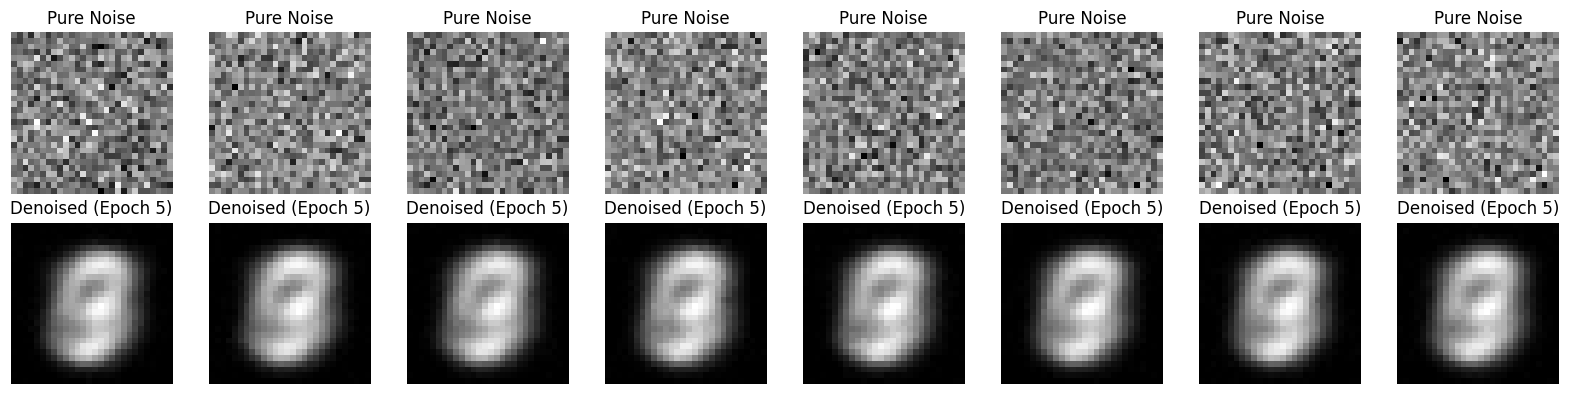

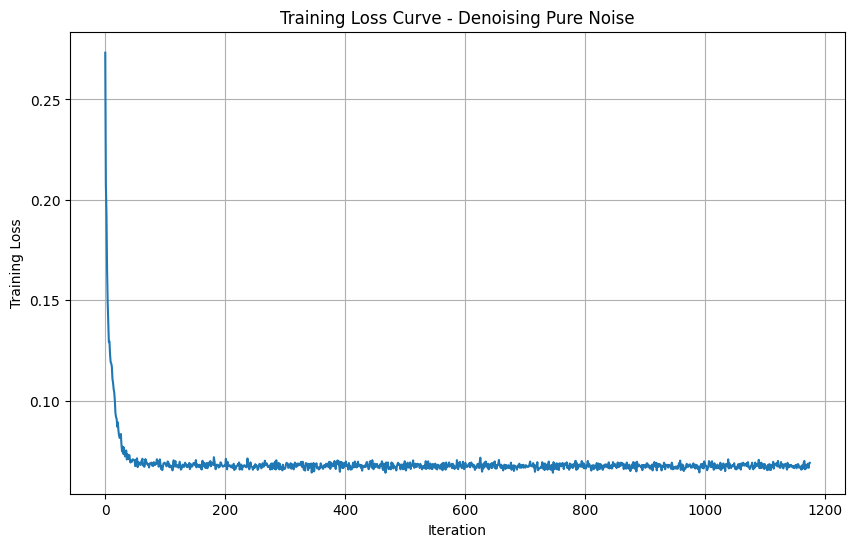

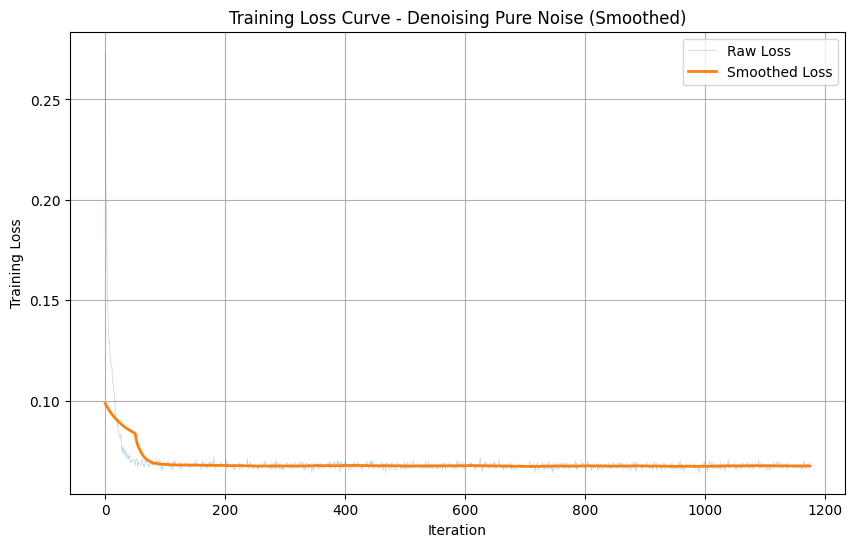


Sampling from the trained denoiser...


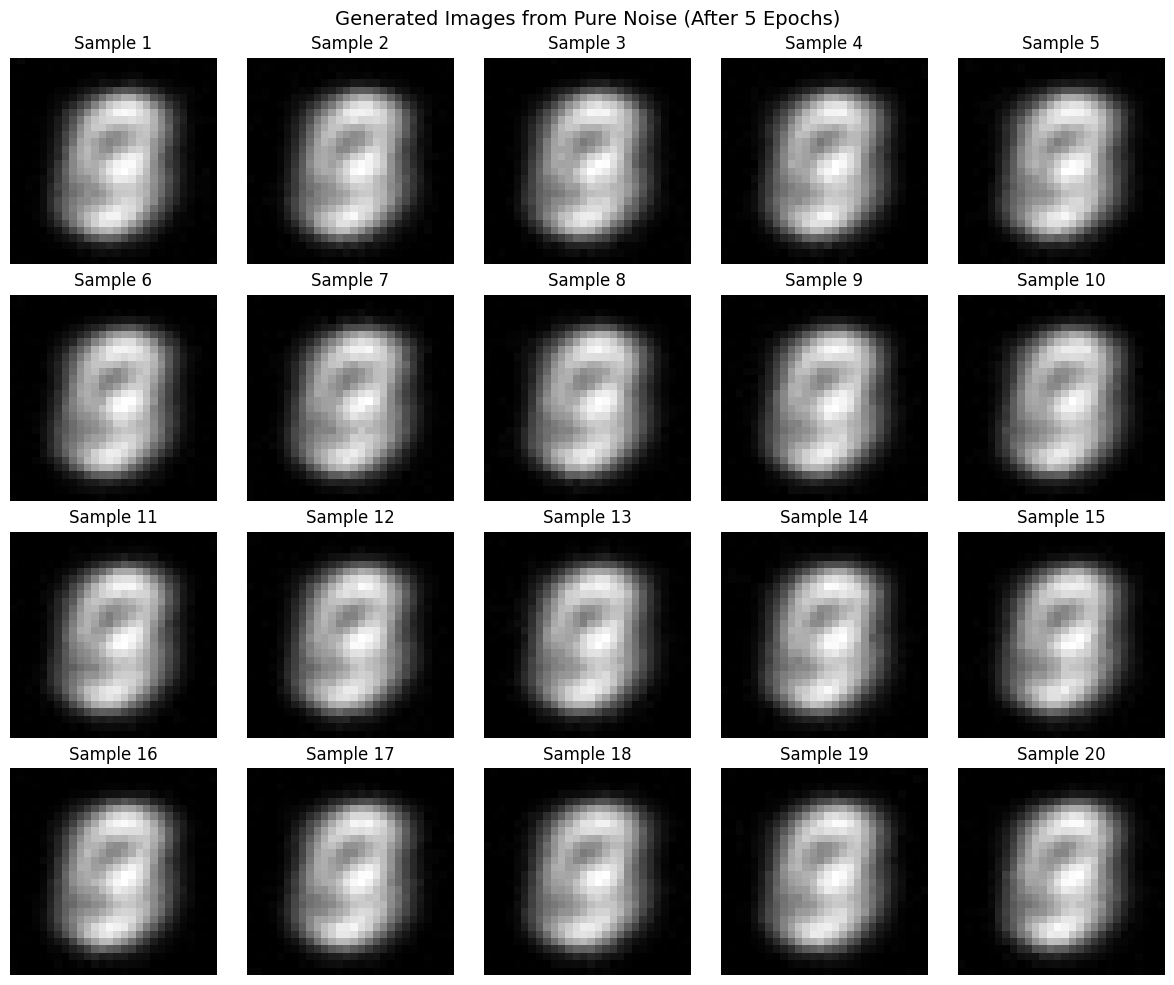


Analysis of Generated Patterns:

The generated outputs from denoising pure noise show interesting patterns:

1. **Blurry/Averaged Appearance**: The generated images appear blurry and lack sharp details. 
   This is because the model learns to predict the mean (centroid) of all training examples 
   when given random noise as input.

2. **MSE Loss and Centroid Behavior**: With MSE loss, the model minimizes the sum of squared 
   distances to all training examples. When the input is pure noise (which contains no 
   information about the target), the optimal prediction is the mean of all training images, 
   which acts like a centroid in clustering.

3. **Relationship to Training Images**: The generated images represent an "average" or 
   "centroid" of all MNIST digits (0-9). Since the model sees all digits during training 
   but receives no information about which digit to generate, it produces a blurred 
   combination that minimizes the average distance to all possible digits.

4. 

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar

import os
from google.colab import drive

# Mount Google Drive for checkpointing
drive.mount('/content/drive')
checkpoint_dir = '/content/drive/MyDrive/denoising_pure_noise_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set hyperparameters (same as part 1.2.1)
batch_size = 256
learning_rate = 1e-4
hidden_dim = 128  # D = 128
num_epochs = 5

# Define datasets and dataloaders
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define model, optimizer, and loss
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Check if checkpoint exists and load it
start_epoch = 0
checkpoint_path = os.path.join(checkpoint_dir, 'checkpoint_epoch_5.pth')
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    train_losses = checkpoint['train_losses']
    print(f"Resumed from epoch {start_epoch}")
else:
    train_losses = []

# Training loop - denoising pure noise
model.train()

for epoch in range(start_epoch, num_epochs):
    epoch_losses = []

    for i, (images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        # Move images to device
        images = images.to(device)

        # KEY DIFFERENCE: Input is pure noise epsilon ~ N(0, I)
        # Instead of z = x + sigma * epsilon, we use z = epsilon
        epsilon = torch.randn_like(images)

        # Model predicts denoised image from pure noise
        outputs = model(epsilon)

        # Target is still the clean images
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        epoch_losses.append(loss.item())

    # Print average loss for this epoch
    avg_loss = np.mean(epoch_losses)
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.6f}')

    # Save checkpoint after each epoch
    checkpoint_path_epoch = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
    }, checkpoint_path_epoch)
    print(f'Checkpoint saved to {checkpoint_path_epoch}')

    # Visualize denoised results on pure noise after 1st and 5th epoch
    if epoch == 0 or epoch == num_epochs - 1:
        model.eval()
        with torch.no_grad():
            # Generate pure noise samples
            num_samples = 8
            pure_noise = torch.randn(num_samples, 1, 28, 28).to(device)

            # Denoise the pure noise
            denoised = model(pure_noise)
            # Clamp denoised output to [0, 1] for visualization
            denoised = torch.clamp(denoised, 0, 1)

            # Visualize results
            fig, axes = plt.subplots(2, num_samples, figsize=(16, 4))
            for idx in range(num_samples):
                # Pure noise input
                axes[0, idx].imshow(pure_noise[idx].cpu().squeeze(), cmap='gray')
                axes[0, idx].set_title('Pure Noise')
                axes[0, idx].axis('off')

                # Denoised output
                axes[1, idx].imshow(denoised[idx].cpu().squeeze(), cmap='gray')
                axes[1, idx].set_title(f'Denoised (Epoch {epoch+1})')
                axes[1, idx].axis('off')

            plt.tight_layout()
            os.makedirs('denoising_results_unet', exist_ok=True)
            plt.savefig(f'denoising_results_unet/pure_noise_denoised_epoch_{epoch+1}.png', dpi=150, bbox_inches='tight')
            plt.show()

        model.train()

# Visualize training loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve - Denoising Pure Noise')
plt.grid(True)
os.makedirs('denoising_results_unet', exist_ok=True)
plt.savefig('denoising_results_unet/training_loss_curve_pure_noise.png', dpi=150, bbox_inches='tight')
plt.show()

# Also plot smoothed version (moving average)
window_size = 100
if len(train_losses) > window_size:
    smoothed_losses = []
    for i in range(len(train_losses)):
        start_idx = max(0, i - window_size // 2)
        end_idx = min(len(train_losses), i + window_size // 2)
        smoothed_losses.append(np.mean(train_losses[start_idx:end_idx]))

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, alpha=0.3, label='Raw Loss', linewidth=0.5)
    plt.plot(smoothed_losses, label='Smoothed Loss', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Curve - Denoising Pure Noise (Smoothed)')
    plt.legend()
    plt.grid(True)
    plt.savefig('denoising_results_unet/training_loss_curve_pure_noise_smoothed.png', dpi=150, bbox_inches='tight')
    plt.show()

# Sample from the trained denoiser to observe patterns
print("\n" + "="*50)
print("Sampling from the trained denoiser...")
print("="*50)

model.eval()
with torch.no_grad():
    # Generate multiple samples from pure noise
    num_generated_samples = 20
    pure_noise_samples = torch.randn(num_generated_samples, 1, 28, 28).to(device)

    generated_images = model(pure_noise_samples)
    generated_images = torch.clamp(generated_images, 0, 1)

    # Visualize generated samples
    fig, axes = plt.subplots(4, 5, figsize=(12, 10))
    for idx in range(num_generated_samples):
        row = idx // 5
        col = idx % 5
        axes[row, col].imshow(generated_images[idx].cpu().squeeze(), cmap='gray')
        axes[row, col].set_title(f'Sample {idx+1}')
        axes[row, col].axis('off')

    plt.suptitle('Generated Images from Pure Noise (After 5 Epochs)', fontsize=14)
    plt.tight_layout()
    plt.savefig('denoising_results_unet/generated_samples_from_pure_noise.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "="*50)
print("Analysis of Generated Patterns:")
print("="*50)
print("""
The generated outputs from denoising pure noise show interesting patterns:

1. **Blurry/Averaged Appearance**: The generated images appear blurry and lack sharp details.
   This is because the model learns to predict the mean (centroid) of all training examples
   when given random noise as input.

2. **MSE Loss and Centroid Behavior**: With MSE loss, the model minimizes the sum of squared
   distances to all training examples. When the input is pure noise (which contains no
   information about the target), the optimal prediction is the mean of all training images,
   which acts like a centroid in clustering.

3. **Relationship to Training Images**: The generated images represent an "average" or
   "centroid" of all MNIST digits (0-9). Since the model sees all digits during training
   but receives no information about which digit to generate, it produces a blurred
   combination that minimizes the average distance to all possible digits.

4. **Why This Happens**:
   - The model is trained to map random noise to clean images
   - Without any conditioning or guidance, it learns to predict the point that minimizes
     the expected squared error across all training examples
   - This point is the mean/centroid of the training distribution
   - For MNIST, this results in a blurred "average digit" that doesn't clearly represent
     any specific digit class

This demonstrates the importance of conditioning (like class labels or text prompts)
in generative models to produce diverse and meaningful outputs rather than just the
centroid of the training distribution.
""")


# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [ ]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.fc1 = nn.Linear(in_channels, out_channels)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(out_channels, out_channels)


    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x = self.fc1(x)
        x = self.gelu(x)
        x = self.fc2(x)
        return x



class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()

        # Time conditioning: two FCBlocks for modulating unflatten and up1
        # fc1_t: conditions unflatten output (2*num_hiddens channels)
        self.fc1_t = FCBlock(1, 2 * num_hiddens)
        # fc2_t: conditions up1 output (num_hiddens channels)
        self.fc2_t = FCBlock(1, num_hiddens)

        # Encoder path (same as UnconditionalUNet)
        self.conv_block_in = ConvBlock(in_channels, num_hiddens)
        self.down_block1 = DownBlock(num_hiddens, num_hiddens)
        self.down_block2 = DownBlock(num_hiddens, 2 * num_hiddens)

        # Bottleneck
        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * num_hiddens)

        # Decoder path
        self.up_block1 = UpBlock(4 * num_hiddens, num_hiddens)  # 4*num_hiddens after concat
        self.up_block2 = UpBlock(2 * num_hiddens, num_hiddens)  # 2*num_hiddens after concat

        self.conv_block_out = ConvBlock(2 * num_hiddens, num_hiddens)  # 2*num_hiddens after concat

        # Final output layer (just Conv2d, no BN/GELU)
        self.final_conv = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, stride=1, padding=1)


    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        # Embed time t (scalar) using FCBlocks
        # t is (N,) normalized to [0, 1], need to reshape to (N, 1) for FCBlock
        t_input = t.unsqueeze(-1)  # (N,) -> (N, 1)

        # Get time embeddings for conditioning
        t1 = self.fc1_t(t_input)  # (N, 1) -> (N, 2*num_hiddens)
        t2 = self.fc2_t(t_input)  # (N, 1) -> (N, num_hiddens)

        # Encoder path (no time conditioning)
        x1 = self.conv_block_in(x)  # (N, num_hiddens, 28, 28)
        x2 = self.down_block1(x1)  # (N, num_hiddens, 14, 14)
        x3 = self.down_block2(x2)  # (N, 2*num_hiddens, 7, 7)

        # Bottleneck
        x4 = self.flatten(x3)  # (N, 2*num_hiddens, 1, 1)
        x5 = self.unflatten(x4)  # (N, 2*num_hiddens, 7, 7)
        # Condition unflatten output with t1: multiply by t1
        # Reshape t1 from (N, 2*num_hiddens) to (N, 2*num_hiddens, 1, 1) for broadcasting
        x5 = x5 * t1.unsqueeze(-1).unsqueeze(-1)  # (N, 2*num_hiddens, 7, 7)

        # Decoder path with skip connections
        x6 = torch.cat([x5, x3], dim=1)  # (N, 4*num_hiddens, 7, 7)
        x7 = self.up_block1(x6)  # (N, num_hiddens, 14, 14)
        # Condition up1 output with t2: multiply by t2
        # Reshape t2 from (N, num_hiddens) to (N, num_hiddens, 1, 1) for broadcasting
        x7 = x7 * t2.unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens, 14, 14)

        x8 = torch.cat([x7, x2], dim=1)  # (N, 2*num_hiddens, 14, 14)
        x9 = self.up_block2(x8)  # (N, num_hiddens, 28, 28)

        x10 = torch.cat([x9, x1], dim=1)  # (N, 2*num_hiddens, 28, 28)
        x11 = self.conv_block_out(x10)  # (N, num_hiddens, 28, 28)

        # Final output
        out = self.final_conv(x11)  # (N, in_channels, 28, 28)
        return out


## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [ ]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()

    batch_size = x_1.shape[0]
    device = x_1.device

    # Sample x_0 ~ N(0, I) - pure noise
    x_0 = torch.randn_like(x_1)

    # Sample t ~ U[0, 1] - uniform random time for each sample
    t = torch.rand(batch_size, device=device)  # (N,)

    # Compute x_t = (1-t)x_0 + tx_1 (interpolated noisy image)
    # Reshape t to (N, 1, 1, 1) for broadcasting
    t_expanded = t.view(batch_size, 1, 1, 1)  # (N, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1  # (N, C, H, W)

    # Get model prediction: u_θ(x_t, t)
    u_pred = unet(x_t, t)  # (N, C, H, W)

    # Compute target flow: u_target = x_1 - x_0
    u_target = x_1 - x_0  # (N, C, H, W)

    # Compute MSE loss: ||u_target - u_pred||^2
    loss = torch.mean((u_target - u_pred) ** 2)

    return loss


In [ ]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()

    # Set random seed for reproducibility
    torch.manual_seed(seed)

    H, W = img_wh
    # For MNIST: C=1, generate 1 sample (N=1)
    # You can modify N if you want to generate multiple samples
    N = 1
    C = 1
    device = next(unet.parameters()).device

    # Initialize x_0 ~ N(0, I) - pure noise at t=0
    x_t = torch.randn(N, C, H, W, device=device)

    # Time step size: go from t=0 to t=1 in num_ts steps
    dt = 1.0 / num_ts

    # Solve ODE: dx_t/dt = u_θ(x_t, t) using Euler's method
    # Iterate from t=0 to t=1
    for step in range(num_ts):
        # Current time: t in [0, 1]
        t = torch.full((N,), step * dt, device=device)  # (N,)

        # Predict flow: u_θ(x_t, t)
        u_pred = unet(x_t, t)  # (N, C, H, W)

        # Euler step: x_{t+dt} = x_t + dt * u_θ(x_t, t)
        x_t = x_t + dt * u_pred

    # Return final sample at t=1
    return x_t


In [ ]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

Epoch 1/10: 100%|██████████| 938/938 [00:43<00:00, 21.67it/s]


Epoch 1/10, Average Loss: 0.162090, LR: 0.009500
Checkpoint saved: checkpoint_time_conditional_epoch_1.pth


Epoch 2/10: 100%|██████████| 938/938 [00:43<00:00, 21.55it/s]


Epoch 2/10, Average Loss: 0.118329, LR: 0.009025


Epoch 3/10: 100%|██████████| 938/938 [00:43<00:00, 21.76it/s]


...

Epoch 8/10, Average Loss: 0.096008, LR: 0.006634


Epoch 9/10: 100%|██████████| 938/938 [00:43<00:00, 21.71it/s]


Epoch 9/10, Average Loss: 0.094557, LR: 0.006302


Epoch 10/10: 100%|██████████| 938/938 [00:42<00:00, 21.95it/s]


Epoch 10/10, Average Loss: 0.093629, LR: 0.005987
Checkpoint saved: checkpoint_time_conditional_epoch_10.pth


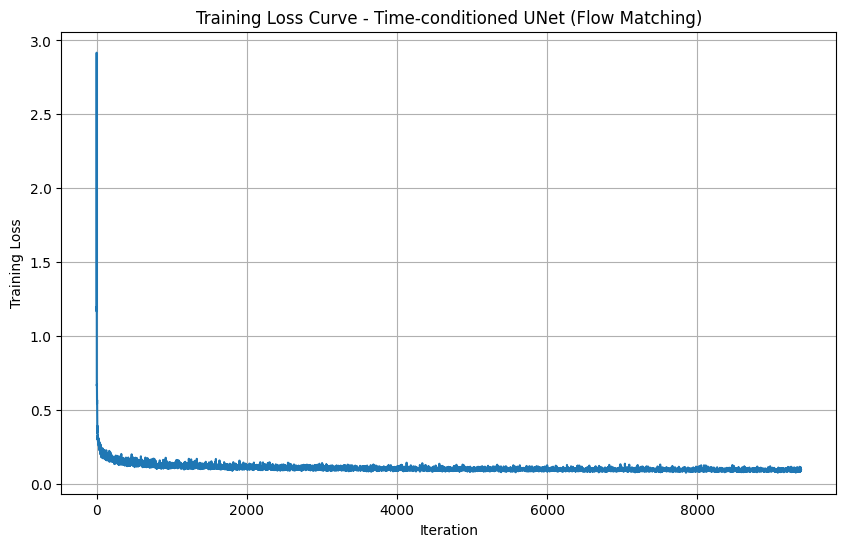

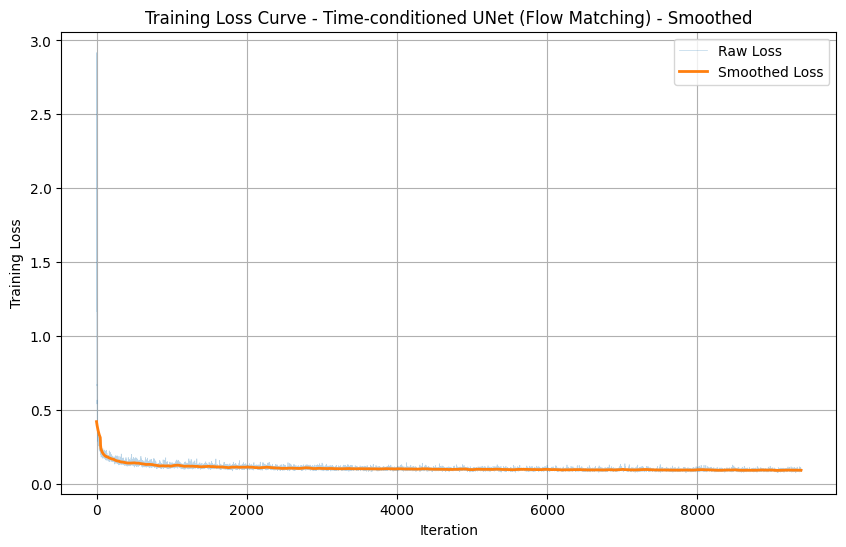


Training completed! Total iterations: 9380
Final average loss: 0.093447


In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set hyperparameters
batch_size = 64
learning_rate = 1e-2
num_hiddens = 64  # D = 64
num_epochs = 10  # Adjust as needed
num_ts = 50  # Number of timesteps for flow matching
scheduler_gamma = 0.95  # Exponential decay factor

# Define datasets and dataloaders
# Use only training set, shuffle before creating dataloader
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define model
# TimeConditionalUNet requires: in_channels, num_classes, num_hiddens
# For MNIST: in_channels=1, num_classes=10 (not used but required), num_hiddens=64
unet = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=num_hiddens).to(device)

# Wrap in TimeConditionalFM for easier training
model = TimeConditionalFM(unet=unet, num_ts=num_ts, img_hw=(28, 28)).to(device)

# Define optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=scheduler_gamma)

# Training loop
train_losses = []
model.train()

for epoch in range(num_epochs):
    epoch_losses = []

    for images, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
        # Move images to device
        images = images.to(device)

        # Forward pass: model.forward(x_1) computes the flow matching loss
        # This internally calls time_fm_forward which:
        # - Samples x_0 ~ N(0, I)
        # - Samples t ~ U[0, 1]
        # - Computes x_t = (1-t)x_0 + tx_1
        # - Predicts flow and computes loss
        loss = model(images)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        epoch_losses.append(loss.item())

    # Step scheduler after each epoch
    scheduler.step()

    # Print average loss for this epoch
    avg_loss = np.mean(epoch_losses)
    current_lr = scheduler.get_last_lr()[0]
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.6f}, LR: {current_lr:.6f}')

    # Save checkpoint at epochs 1, 5, and 10
    if (epoch + 1) in [1, 5, 10]:
        checkpoint_path = f'checkpoint_time_conditional_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'unet_state_dict': unet.state_dict(),
            'num_hiddens': num_hiddens,
            'num_ts': num_ts,
        }, checkpoint_path)
        print(f'Checkpoint saved: {checkpoint_path}')

# Visualize training loss curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve - Time-conditioned UNet (Flow Matching)')
plt.grid(True)
plt.savefig('training_loss_curve_time_conditional.png', dpi=150, bbox_inches='tight')
plt.show()

# Also plot smoothed version (moving average)
window_size = 100
if len(train_losses) > window_size:
    smoothed_losses = []
    for i in range(len(train_losses)):
        start_idx = max(0, i - window_size // 2)
        end_idx = min(len(train_losses), i + window_size // 2)
        smoothed_losses.append(np.mean(train_losses[start_idx:end_idx]))

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, alpha=0.3, label='Raw Loss', linewidth=0.5)
    plt.plot(smoothed_losses, label='Smoothed Loss', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Curve - Time-conditioned UNet (Flow Matching) - Smoothed')
    plt.legend()
    plt.grid(True)
    plt.savefig('training_loss_curve_time_conditional_smoothed.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'\nTraining completed! Total iterations: {len(train_losses)}')
print(f'Final average loss: {np.mean(train_losses[-100:]):.6f}')


# Part 2.3: Sampling from the Time-conditioned UNet


Generating samples from epoch 1
Generating 8 samples...
Saved samples to: time_conditional_samples/samples_epoch_1.png


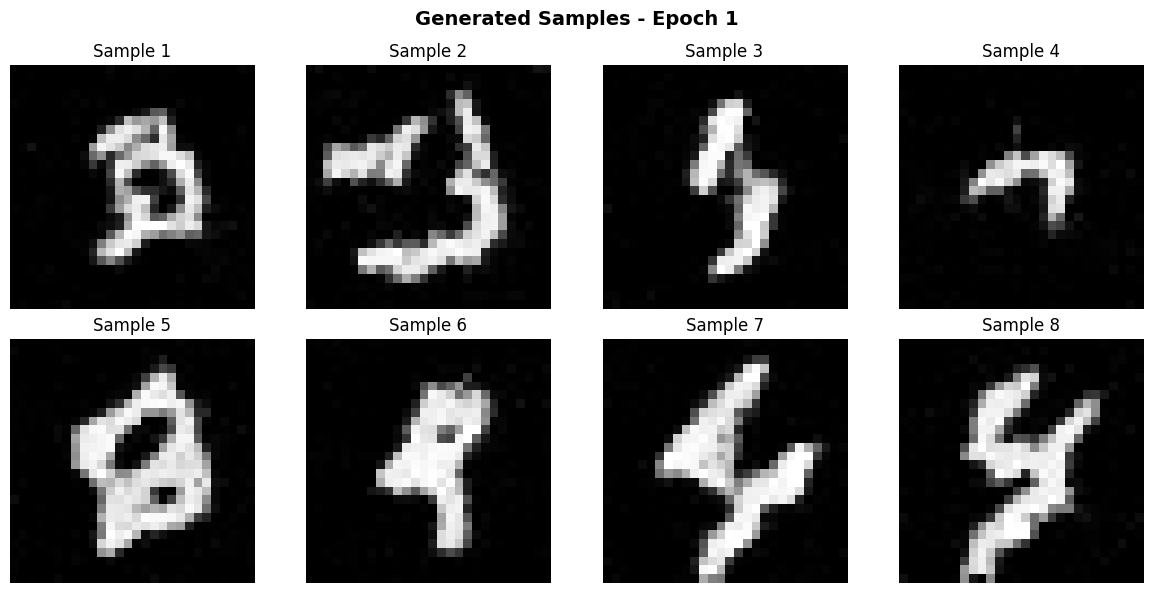


Generating samples from epoch 5
Generating 8 samples...
Saved samples to: time_conditional_samples/samples_epoch_5.png


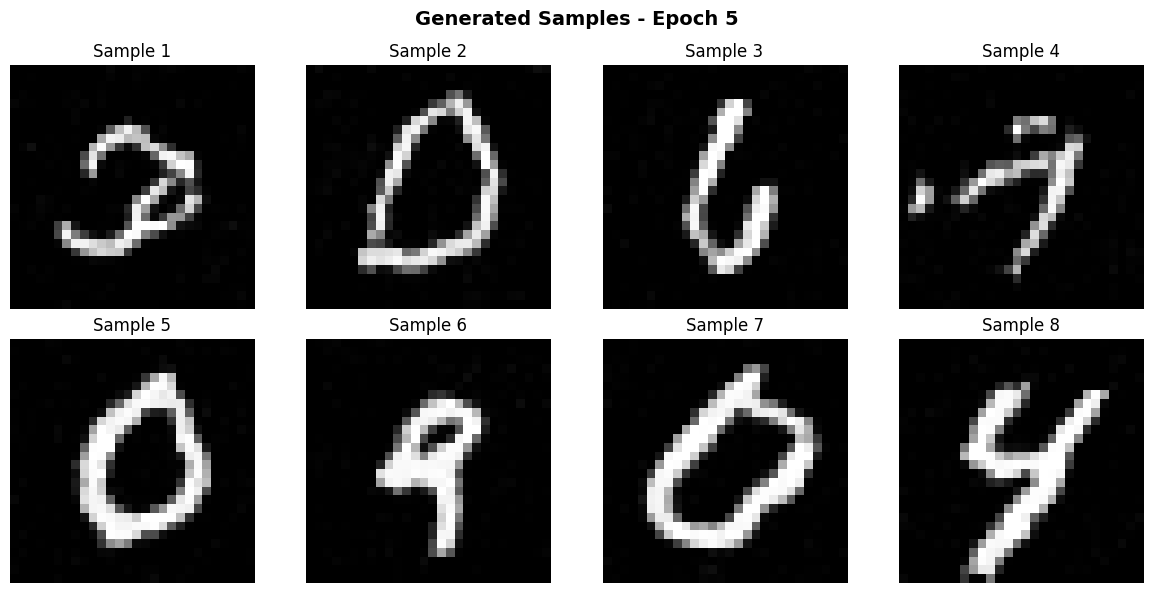


Generating samples from epoch 10
Generating 8 samples...
Saved samples to: time_conditional_samples/samples_epoch_10.png


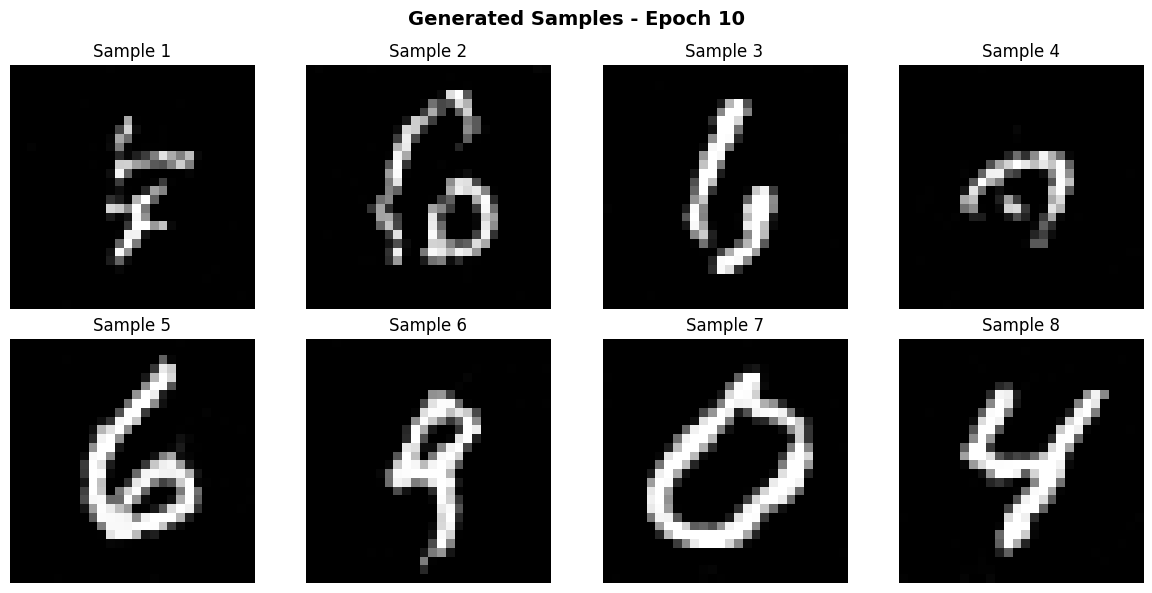


Sampling completed!


In [ ]:
# Sampling from the UNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters (should match training)
num_hiddens = 64
num_ts = 50
num_samples = 8  # Number of samples to generate
img_wh = (28, 28)

# Epochs to sample from
epochs_to_sample = [1, 5, 10]

# Create directory for saving samples
import os
os.makedirs('time_conditional_samples', exist_ok=True)

# Generate samples for each epoch
for epoch in epochs_to_sample:
    print(f'\n{"="*50}')
    print(f'Generating samples from epoch {epoch}')
    print(f'{"="*50}')

    # Load checkpoint
    checkpoint_path = f'drive/MyDrive/time_cond_checkpoints/checkpoint_time_conditional_epoch_{epoch}.pth'

    if not os.path.exists(checkpoint_path):
        print(f'Warning: Checkpoint {checkpoint_path} not found. Skipping epoch {epoch}.')
        print('Make sure you have trained the model and saved checkpoints at epochs 1, 5, and 10.')
        continue

    # Load model
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Recreate model architecture
    unet = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=checkpoint['num_hiddens']).to(device)
    model = TimeConditionalFM(unet=unet, num_ts=checkpoint['num_ts'], img_hw=img_wh).to(device)

    # Load state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Generate samples
    print(f'Generating {num_samples} samples...')
    all_samples = []

    with torch.no_grad():
        for i in range(num_samples):
            # Generate one sample at a time (time_fm_sample generates 1 sample by default)
            sample = time_fm_sample(
                unet=unet,
                img_wh=img_wh,
                num_ts=checkpoint['num_ts'],
                seed=i  # Different seed for each sample
            )
            all_samples.append(sample.cpu())

    # Stack all samples
    samples_tensor = torch.cat(all_samples, dim=0)  # (num_samples, 1, 28, 28)

    # Clamp values to [0, 1] for visualization
    samples_tensor = torch.clamp(samples_tensor, 0, 1)

    # Visualize samples
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for idx in range(num_samples):
        row = idx // 4
        col = idx % 4
        axes[row, col].imshow(samples_tensor[idx].squeeze(), cmap='gray')
        axes[row, col].set_title(f'Sample {idx+1}')
        axes[row, col].axis('off')

    plt.suptitle(f'Generated Samples - Epoch {epoch}', fontsize=14, fontweight='bold')
    plt.tight_layout()

    # Save figure
    save_path = f'time_conditional_samples/samples_epoch_{epoch}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved samples to: {save_path}')
    plt.show()

print(f'\n{"="*50}')
print('Sampling completed!')
print(f'{"="*50}')


# Part 2.4: Implementing a Class-conditioned UNet

In [ ]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()

        # Time conditioning: two FCBlocks for modulating unflatten and up1
        # fc1_t: conditions unflatten output (2*num_hiddens channels)
        self.fc1_t = FCBlock(1, 2 * num_hiddens)
        # fc2_t: conditions up1 output (num_hiddens channels)
        self.fc2_t = FCBlock(1, num_hiddens)

        # Class conditioning: two FCBlocks for modulating unflatten and up1
        # fc1_c: conditions unflatten output (2*num_hiddens channels)
        self.fc1_c = FCBlock(num_classes, 2 * num_hiddens)
        # fc2_c: conditions up1 output (num_hiddens channels)
        self.fc2_c = FCBlock(num_classes, num_hiddens)

        # Encoder path (same as UnconditionalUNet)
        self.conv_block_in = ConvBlock(in_channels, num_hiddens)
        self.down_block1 = DownBlock(num_hiddens, num_hiddens)
        self.down_block2 = DownBlock(num_hiddens, 2 * num_hiddens)

        # Bottleneck
        self.flatten = Flatten()
        self.unflatten = Unflatten(2 * num_hiddens)

        # Decoder path
        self.up_block1 = UpBlock(4 * num_hiddens, num_hiddens)  # 4*num_hiddens after concat
        self.up_block2 = UpBlock(2 * num_hiddens, num_hiddens)  # 2*num_hiddens after concat

        self.conv_block_out = ConvBlock(2 * num_hiddens, num_hiddens)  # 2*num_hiddens after concat

        # Final output layer (just Conv2d, no BN/GELU)
        self.final_conv = nn.Conv2d(num_hiddens, in_channels, kernel_size=3, stride=1, padding=1)


    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."

        batch_size = x.shape[0]
        device = x.device

        # Convert class vector c to one-hot encoding
        # c is (N,) int64, convert to (N, num_classes) one-hot
        num_classes = self.fc1_c.fc1.in_features  # Get num_classes from fc1_c
        c_onehot = torch.zeros(batch_size, num_classes, device=device)
        c_onehot.scatter_(1, c.unsqueeze(1), 1.0)  # (N, num_classes)

        # Apply mask if provided (for classifier-free guidance)
        # If mask is not None and mask[i] == 0, set c_onehot[i] to zero vector
        if mask is not None:
            # mask is (N,), expand to (N, num_classes) for broadcasting
            mask_expanded = mask.unsqueeze(1)  # (N, 1)
            c_onehot = c_onehot * mask_expanded  # (N, num_classes)

        # Embed time t (scalar) using FCBlocks
        # t is (N,) normalized to [0, 1], need to reshape to (N, 1) for FCBlock
        t_input = t.unsqueeze(-1)  # (N,) -> (N, 1)

        # Get time embeddings for conditioning
        t1 = self.fc1_t(t_input)  # (N, 1) -> (N, 2*num_hiddens)
        t2 = self.fc2_t(t_input)  # (N, 1) -> (N, num_hiddens)

        # Get class embeddings for conditioning
        c1 = self.fc1_c(c_onehot)  # (N, num_classes) -> (N, 2*num_hiddens)
        c2 = self.fc2_c(c_onehot)  # (N, num_classes) -> (N, num_hiddens)

        # Encoder path (no conditioning)
        x1 = self.conv_block_in(x)  # (N, num_hiddens, 28, 28)
        x2 = self.down_block1(x1)  # (N, num_hiddens, 14, 14)
        x3 = self.down_block2(x2)  # (N, 2*num_hiddens, 7, 7)

        # Bottleneck
        x4 = self.flatten(x3)  # (N, 2*num_hiddens, 1, 1)
        x5 = self.unflatten(x4)  # (N, 2*num_hiddens, 7, 7)

        # Modulate unflatten output: unflatten = c1 * unflatten + t1
        # Reshape c1 and t1 from (N, 2*num_hiddens) to (N, 2*num_hiddens, 1, 1) for broadcasting
        c1_expanded = c1.unsqueeze(-1).unsqueeze(-1)  # (N, 2*num_hiddens, 1, 1)
        t1_expanded = t1.unsqueeze(-1).unsqueeze(-1)  # (N, 2*num_hiddens, 1, 1)
        x5 = c1_expanded * x5 + t1_expanded  # (N, 2*num_hiddens, 7, 7)

        # Decoder path with skip connections
        x6 = torch.cat([x5, x3], dim=1)  # (N, 4*num_hiddens, 7, 7)
        x7 = self.up_block1(x6)  # (N, num_hiddens, 14, 14)

        # Modulate up1 output: up1 = c2 * up1 + t2
        # Reshape c2 and t2 from (N, num_hiddens) to (N, num_hiddens, 1, 1) for broadcasting
        c2_expanded = c2.unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens, 1, 1)
        t2_expanded = t2.unsqueeze(-1).unsqueeze(-1)  # (N, num_hiddens, 1, 1)
        x7 = c2_expanded * x7 + t2_expanded  # (N, num_hiddens, 14, 14)

        x8 = torch.cat([x7, x2], dim=1)  # (N, 2*num_hiddens, 14, 14)
        x9 = self.up_block2(x8)  # (N, num_hiddens, 28, 28)

        x10 = torch.cat([x9, x1], dim=1)  # (N, 2*num_hiddens, 28, 28)
        x11 = self.conv_block_out(x10)  # (N, num_hiddens, 28, 28)

        # Final output
        out = self.final_conv(x11)  # (N, in_channels, 28, 28)
        return out


In [ ]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()

    batch_size = x_1.shape[0]
    device = x_1.device

    # Sample x_0 ~ N(0, I) - pure noise
    x_0 = torch.randn_like(x_1)

    # Sample t ~ U[0, 1] - uniform random time for each sample
    t = torch.rand(batch_size, device=device)  # (N,)

    # Compute x_t = (1-t)x_0 + tx_1 (interpolated noisy image)
    # Reshape t to (N, 1, 1, 1) for broadcasting
    t_expanded = t.view(batch_size, 1, 1, 1)  # (N, 1, 1, 1)
    x_t = (1 - t_expanded) * x_0 + t_expanded * x_1  # (N, C, H, W)

    # Create mask for classifier-free guidance dropout
    # With probability p_uncond, mask out the condition (set mask to 0)
    # mask[i] = 0 means drop condition for sample i, mask[i] = 1 means keep condition
    mask = (torch.rand(batch_size, device=device) > p_uncond).float()  # (N,)

    # Get model prediction: u_θ(x_t, t, c) with potential masking
    u_pred = unet(x_t, c, t, mask=mask)  # (N, C, H, W)

    # Compute target flow: u_target = x_1 - x_0
    u_target = x_1 - x_0  # (N, C, H, W)

    # Compute MSE loss: ||u_target - u_pred||^2
    loss = torch.mean((u_target - u_pred) ** 2)

    return loss


In [ ]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()

    # Set random seed for reproducibility
    torch.manual_seed(seed)

    H, W = img_wh
    N = c.shape[0]  # Number of samples
    C = 1  # For MNIST: C=1
    device = next(unet.parameters()).device

    # Initialize x_0 ~ N(0, I) - pure noise at t=0
    x_t = torch.randn(N, C, H, W, device=device)

    # Time step size: go from t=0 to t=1 in num_ts steps
    dt = 1.0 / num_ts

    # Store intermediate samples for animation (cache)
    # We'll store samples at regular intervals (e.g., every 10 steps)
    cache_interval = max(1, num_ts // 20)  # Store ~20 frames
    caches = []

    # Solve ODE: dx_t/dt = u_θ(x_t, t) using Euler's method with CFG
    # Iterate from t=0 to t=1
    for step in range(num_ts):
        # Current time: t in [0, 1]
        t = torch.full((N,), step * dt, device=device)  # (N,)

        # Classifier-Free Guidance (CFG):
        # u_pred = u_uncond + guidance_scale * (u_cond - u_uncond)
        # where u_cond = u_θ(x_t, t, c) and u_uncond = u_θ(x_t, t, c=0)

        # Get conditional prediction: u_θ(x_t, t, c)
        # mask=None means use the condition normally
        u_cond = unet(x_t, c, t, mask=None)  # (N, C, H, W)

        # Get unconditional prediction: u_θ(x_t, t, c=0)
        # Create zero mask to drop condition
        mask_uncond = torch.zeros(N, device=device)  # (N,)
        # We can use any class label for c_uncond since mask will zero it out
        # But it's cleaner to use zeros
        c_uncond = torch.zeros_like(c)  # (N,)
        u_uncond = unet(x_t, c_uncond, t, mask=mask_uncond)  # (N, C, H, W)

        # Apply CFG: u_pred = u_uncond + guidance_scale * (u_cond - u_uncond)
        u_pred = u_uncond + guidance_scale * (u_cond - u_uncond)  # (N, C, H, W)

        # Euler step: x_{t+dt} = x_t + dt * u_θ(x_t, t)
        x_t = x_t + dt * u_pred

        # Cache intermediate samples for animation
        if step % cache_interval == 0 or step == num_ts - 1:
            caches.append(x_t.clone().cpu())

    # Stack caches: (T_animation, N, C, H, W) -> (N, T_animation, C, H, W)
    if caches:
        caches_tensor = torch.stack(caches, dim=1)  # (N, T_animation, C, H, W)
    else:
        # Fallback: just return final sample as cache
        caches_tensor = x_t.unsqueeze(1).cpu()  # (N, 1, C, H, W)

    # Return final sample at t=1 and caches
    return x_t, caches_tensor


In [ ]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

In [1]:
# Feel free to use code from part 1.2.1
# as they should be very similar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set hyperparameters
batch_size = 64
learning_rate = 1e-3
num_hiddens = 64  # D = 64
num_classes = 10  # MNIST has 10 classes
num_epochs = 10  # Adjust as needed
num_ts = 50  # Number of timesteps for flow matching
p_uncond = 0.1  # Probability of unconditional generation (classifier-free guidance dropout)
scheduler_gamma = 0.95  # Exponential decay factor

# Define datasets and dataloaders
# Use training set, shuffle before creating dataloader
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define model
# ClassConditionalUNet requires: in_channels, num_classes, num_hiddens
# For MNIST: in_channels=1, num_classes=10, num_hiddens=64
unet = ClassConditionalUNet(in_channels=1, num_classes=num_classes, num_hiddens=num_hiddens).to(device)

# Wrap in ClassConditionalFM for easier training
model = ClassConditionalFM(unet=unet, num_ts=num_ts, p_uncond=p_uncond).to(device)

# Define optimizer (NO SCHEDULER - simplicity is best!)
# We'll use a slightly lower learning rate initially to compensate for no decay
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate * 0.9)

# Training loop
train_losses = []
model.train()

for epoch in range(num_epochs):
    epoch_losses = []

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)  # (N,) int64 class labels

        # Forward pass: model.forward(x_1, c) computes the class-conditional flow matching loss
        # This internally calls class_fm_forward which:
        # - Samples x_0 ~ N(0, I)
        # - Samples t ~ U[0, 1]
        # - Computes x_t = (1-t)x_0 + tx_1
        # - With probability p_uncond, masks out the condition c (sets to zero vector)
        # - Predicts flow and computes loss: ||(x_1 - x_0) - u_θ(x_t, t, c)||^2
        loss = model(images, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        epoch_losses.append(loss.item())

    # Print average loss for this epoch
    avg_loss = np.mean(epoch_losses)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.6f}, LR: {current_lr:.6f}')

    # Save checkpoint at epochs 1, 5, and 10
    if (epoch + 1) in [1, 5, 10]:
        checkpoint_path = f'checkpoint_class_conditional_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'unet_state_dict': unet.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'num_hiddens': num_hiddens,
            'num_ts': num_ts,
            'num_classes': num_classes,
            'train_losses': train_losses,
        }, checkpoint_path)
        print(f'Checkpoint saved: {checkpoint_path}')

# Visualize training loss curve (WITHOUT SCHEDULER)
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve - Class-conditioned UNet (NO SCHEDULER)')
plt.grid(True)
plt.savefig('training_loss_curve_class_conditional_no_scheduler.png', dpi=150, bbox_inches='tight')
plt.show()

# Also plot smoothed version (moving average)
window_size = 100
if len(train_losses) > window_size:
    smoothed_losses = []
    for i in range(len(train_losses)):
        start_idx = max(0, i - window_size // 2)
        end_idx = min(len(train_losses), i + window_size // 2)
        smoothed_losses.append(np.mean(train_losses[start_idx:end_idx]))

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, alpha=0.3, label='Raw Loss', linewidth=0.5)
    plt.plot(smoothed_losses, label='Smoothed Loss', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Curve - Class-conditioned UNet (NO SCHEDULER) - Smoothed')
    plt.legend()
    plt.grid(True)
    plt.savefig('training_loss_curve_class_conditional_no_scheduler_smoothed.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'\nTraining completed! Total iterations: {len(train_losses)}')
print(f'Final average loss: {np.mean(train_losses[-100:]):.6f}')

print(f'\n{"="*60}')
print('REMOVING LEARNING RATE SCHEDULER: COMPENSATION STRATEGY')
print(f'{"="*60}')
print(f'{"="*60}\n')


NameError: name 'torch' is not defined


Training Class-Conditioned UNet WITH Learning Rate Scheduler
Initial Learning Rate: 0.01
Scheduler Gamma: 0.95
Learning rate will decay as: LR = 0.01 * 0.95^epoch



Epoch 1/10 (with scheduler): 100%|██████████| 938/938 [00:44<00:00, 21.13it/s]


Epoch 1/10, Average Loss: 0.179713, LR: 0.009500
Checkpoint saved: checkpoint_class_conditional_epoch_1_with_scheduler.pth


Epoch 2/10 (with scheduler): 100%|██████████| 938/938 [00:42<00:00, 22.27it/s]


Epoch 2/10, Average Loss: 0.115464, LR: 0.009025


...

Epoch 8/10, Average Loss: 0.088369, LR: 0.006634


Epoch 9/10 (with scheduler): 100%|██████████| 938/938 [00:42<00:00, 22.03it/s]


Epoch 9/10, Average Loss: 0.087653, LR: 0.006302


Epoch 10/10 (with scheduler): 100%|██████████| 938/938 [00:42<00:00, 22.17it/s]


Epoch 10/10, Average Loss: 0.085615, LR: 0.005987
Checkpoint saved: checkpoint_class_conditional_epoch_10_with_scheduler.pth


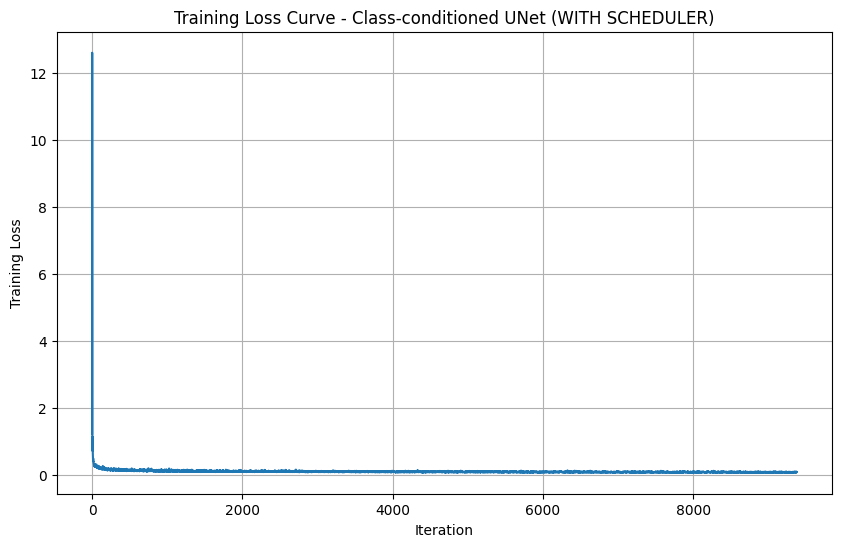

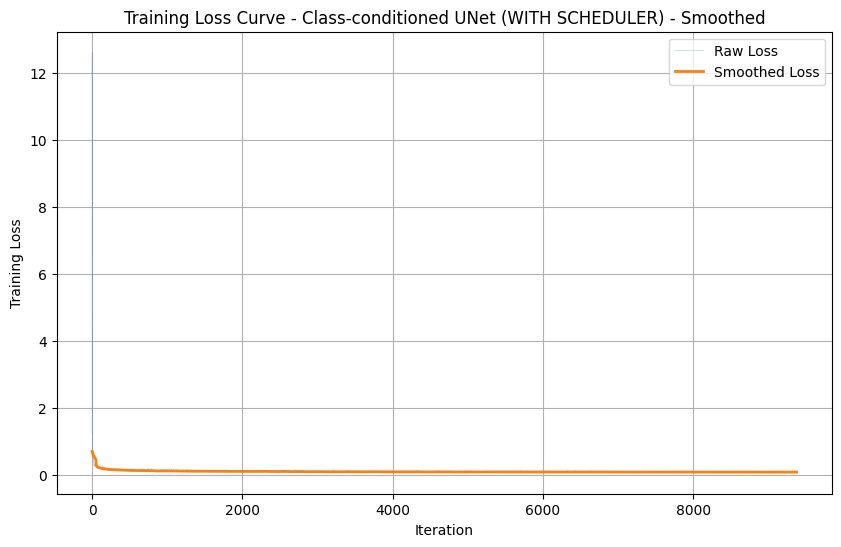

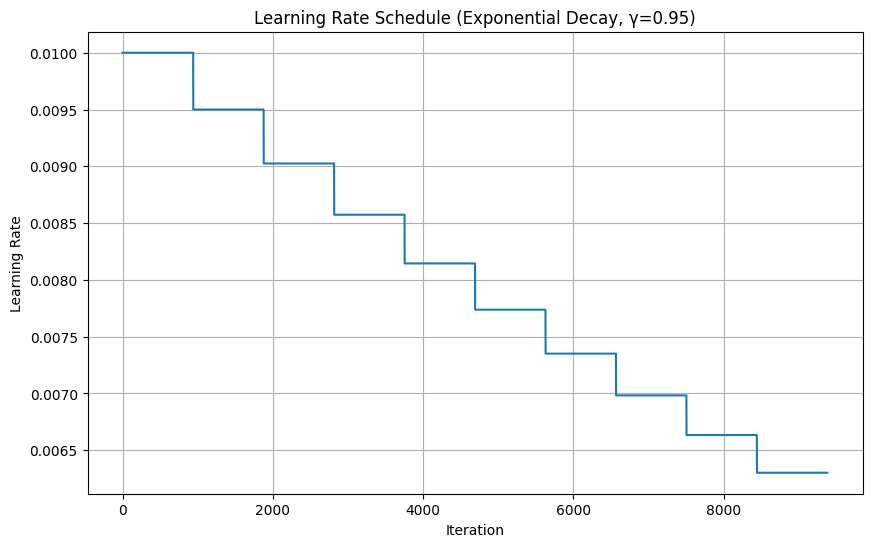


Training completed! Total iterations: 9380
Final average loss: 0.085451
Final learning rate: 0.006302

COMPARING: With Scheduler vs. Without Scheduler
Loaded no-scheduler training losses: 9380 iterations


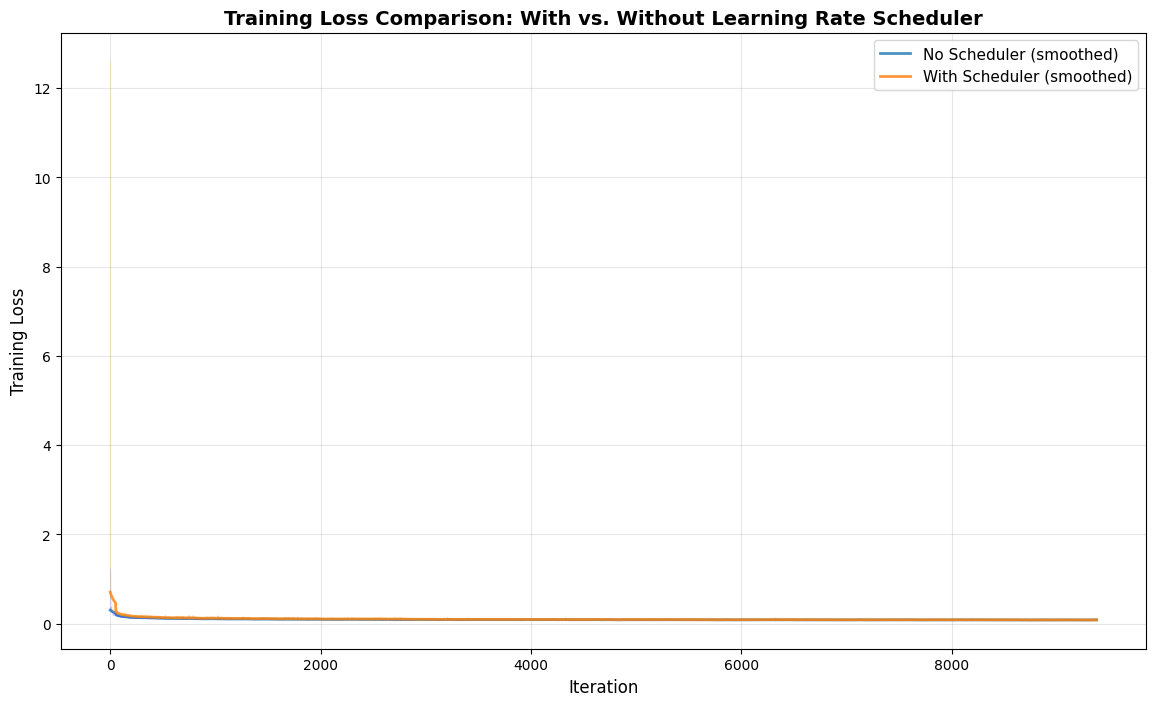


SUMMARY STATISTICS
No Scheduler:
  - Final 100-iteration average: 0.084246
  - Minimum loss: 0.066492
  - Total iterations: 9380

With Scheduler:
  - Final 100-iteration average: 0.085451
  - Minimum loss: 0.068536
  - Total iterations: 9380
  - Initial LR: 0.010000
  - Final LR: 0.006302
  - LR decay factor: 0.6302

Checkpoints saved:
  - With scheduler: checkpoint_class_conditional_epoch_{1,5,10}_with_scheduler.pth
  - No scheduler: checkpoint_class_conditional_epoch_{1,5,10}.pth



In [27]:
# Training Class-Conditioned UNet WITH Learning Rate Scheduler
# This cell trains the model with an exponential LR scheduler and compares with the no-scheduler version

import os
import torch.optim.lr_scheduler as lr_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set hyperparameters (same as before)
batch_size = 64
learning_rate = 1e-2  # Full learning rate since we'll use scheduler
num_hiddens = 64  # D = 64
num_classes = 10  # MNIST has 10 classes
num_epochs = 10  # Adjust as needed
num_ts = 50  # Number of timesteps for flow matching
p_uncond = 0.1  # Probability of unconditional generation (classifier-free guidance dropout)
scheduler_gamma = 0.95  # Exponential decay factor

# Define datasets and dataloaders
# Use training set, shuffle before creating dataloader
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define model (fresh instance for fair comparison)
unet_scheduler = ClassConditionalUNet(in_channels=1, num_classes=num_classes, num_hiddens=num_hiddens).to(device)

# Wrap in ClassConditionalFM for easier training
model_scheduler = ClassConditionalFM(unet=unet_scheduler, num_ts=num_ts, p_uncond=p_uncond).to(device)

# Define optimizer WITH SCHEDULER
optimizer_scheduler = torch.optim.Adam(model_scheduler.parameters(), lr=learning_rate)

# Define exponential learning rate scheduler
# Decays learning rate by gamma each epoch: lr = lr * gamma^epoch
scheduler = lr_scheduler.ExponentialLR(optimizer_scheduler, gamma=scheduler_gamma)

# Training loop WITH SCHEDULER
train_losses_scheduler = []
learning_rates_scheduler = []  # Track LR over time
model_scheduler.train()

print(f'\n{"="*60}')
print('Training Class-Conditioned UNet WITH Learning Rate Scheduler')
print(f'{"="*60}')
print(f'Initial Learning Rate: {learning_rate}')
print(f'Scheduler Gamma: {scheduler_gamma}')
print(f'Learning rate will decay as: LR = {learning_rate} * {scheduler_gamma}^epoch')
print(f'{"="*60}\n')

for epoch in range(num_epochs):
    epoch_losses = []

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} (with scheduler)'):
        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)  # (N,) int64 class labels

        # Forward pass
        loss = model_scheduler(images, labels)

        # Backward pass
        optimizer_scheduler.zero_grad()
        loss.backward()
        optimizer_scheduler.step()

        train_losses_scheduler.append(loss.item())
        epoch_losses.append(loss.item())
        learning_rates_scheduler.append(optimizer_scheduler.param_groups[0]['lr'])

    # Step the scheduler at the end of each epoch
    scheduler.step()

    # Print average loss for this epoch
    avg_loss = np.mean(epoch_losses)
    current_lr = optimizer_scheduler.param_groups[0]['lr']
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.6f}, LR: {current_lr:.6f}')

    # Save checkpoint at epochs 1, 5, and 10 (with different names)
    if (epoch + 1) in [1, 5, 10]:
        checkpoint_path = f'checkpoint_class_conditional_epoch_{epoch+1}_with_scheduler.pth'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_scheduler.state_dict(),
            'unet_state_dict': unet_scheduler.state_dict(),
            'optimizer_state_dict': optimizer_scheduler.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'num_hiddens': num_hiddens,
            'num_ts': num_ts,
            'num_classes': num_classes,
            'train_losses': train_losses_scheduler,
            'learning_rates': learning_rates_scheduler,
            'scheduler_gamma': scheduler_gamma,
            'initial_lr': learning_rate,
        }, checkpoint_path)
        print(f'Checkpoint saved: {checkpoint_path}')

# Visualize training loss curve (WITH SCHEDULER)
plt.figure(figsize=(10, 6))
plt.plot(train_losses_scheduler)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve - Class-conditioned UNet (WITH SCHEDULER)')
plt.grid(True)
plt.savefig('training_loss_curve_class_conditional_with_scheduler.png', dpi=150, bbox_inches='tight')
plt.show()

# Also plot smoothed version (moving average)
window_size = 100
if len(train_losses_scheduler) > window_size:
    smoothed_losses_scheduler = []
    for i in range(len(train_losses_scheduler)):
        start_idx = max(0, i - window_size // 2)
        end_idx = min(len(train_losses_scheduler), i + window_size // 2)
        smoothed_losses_scheduler.append(np.mean(train_losses_scheduler[start_idx:end_idx]))

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses_scheduler, alpha=0.3, label='Raw Loss', linewidth=0.5)
    plt.plot(smoothed_losses_scheduler, label='Smoothed Loss', linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Curve - Class-conditioned UNet (WITH SCHEDULER) - Smoothed')
    plt.legend()
    plt.grid(True)
    plt.savefig('training_loss_curve_class_conditional_with_scheduler_smoothed.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot learning rate schedule
plt.figure(figsize=(10, 6))
plt.plot(learning_rates_scheduler)
plt.xlabel('Iteration')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (Exponential Decay, γ=0.95)')
plt.grid(True)
plt.savefig('learning_rate_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTraining completed! Total iterations: {len(train_losses_scheduler)}')
print(f'Final average loss: {np.mean(train_losses_scheduler[-100:]):.6f}')
print(f'Final learning rate: {learning_rates_scheduler[-1]:.6f}')

# ===== COMPARISON: Load no-scheduler results and compare =====
print(f'\n{"="*60}')
print('COMPARING: With Scheduler vs. Without Scheduler')
print(f'{"="*60}')

# Try to load the no-scheduler training losses if checkpoint exists
try:
    # Check if we have a checkpoint from the previous training
    checkpoint_no_scheduler = torch.load('checkpoint_class_conditional_epoch_10.pth', map_location='cpu')
    train_losses_no_scheduler = checkpoint_no_scheduler.get('train_losses', [])
    print(f'Loaded no-scheduler training losses: {len(train_losses_no_scheduler)} iterations')
except FileNotFoundError:
    print('No-scheduler checkpoint not found. Please run the previous training cell first.')
    print('Creating comparison plot with scheduler results only.')
    train_losses_no_scheduler = None

# Create comparison plot
plt.figure(figsize=(14, 8))

# Plot both loss curves
if train_losses_no_scheduler is not None:
    # Smooth both curves for better comparison
    if len(train_losses_no_scheduler) > window_size:
        smoothed_no_scheduler = []
        for i in range(len(train_losses_no_scheduler)):
            start_idx = max(0, i - window_size // 2)
            end_idx = min(len(train_losses_no_scheduler), i + window_size // 2)
            smoothed_no_scheduler.append(np.mean(train_losses_no_scheduler[start_idx:end_idx]))
    else:
        smoothed_no_scheduler = train_losses_no_scheduler

    plt.plot(smoothed_no_scheduler, label='No Scheduler (smoothed)', linewidth=2, alpha=0.8)
    plt.plot(train_losses_no_scheduler, alpha=0.2, linewidth=0.5, color='blue')

if len(train_losses_scheduler) > window_size:
    plt.plot(smoothed_losses_scheduler, label='With Scheduler (smoothed)', linewidth=2, alpha=0.8)
    plt.plot(train_losses_scheduler, alpha=0.2, linewidth=0.5, color='orange')
else:
    plt.plot(train_losses_scheduler, label='With Scheduler', linewidth=2, alpha=0.8)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss Comparison: With vs. Without Learning Rate Scheduler', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_comparison_scheduler_vs_no_scheduler.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f'\n{"="*60}')
print('SUMMARY STATISTICS')
print(f'{"="*60}')
if train_losses_no_scheduler is not None:
    print(f'No Scheduler:')
    print(f'  - Final 100-iteration average: {np.mean(train_losses_no_scheduler[-100:]):.6f}')
    print(f'  - Minimum loss: {np.min(train_losses_no_scheduler):.6f}')
    print(f'  - Total iterations: {len(train_losses_no_scheduler)}')

print(f'\nWith Scheduler:')
print(f'  - Final 100-iteration average: {np.mean(train_losses_scheduler[-100:]):.6f}')
print(f'  - Minimum loss: {np.min(train_losses_scheduler):.6f}')
print(f'  - Total iterations: {len(train_losses_scheduler)}')
print(f'  - Initial LR: {learning_rates_scheduler[0]:.6f}')
print(f'  - Final LR: {learning_rates_scheduler[-1]:.6f}')
print(f'  - LR decay factor: {learning_rates_scheduler[-1] / learning_rates_scheduler[0]:.4f}')

print(f'\n{"="*60}')
print('Checkpoints saved:')
print('  - With scheduler: checkpoint_class_conditional_epoch_{1,5,10}_with_scheduler.pth')
if train_losses_no_scheduler is not None:
    print('  - No scheduler: checkpoint_class_conditional_epoch_{1,5,10}.pth')
print(f'{"="*60}\n')



# Part 2.6: Sampling from the Class-conditioned UNet


Generating samples from epoch 1 with gamma=5.0
Generating 4 instances of each digit (0-9)...
Saved samples to: class_conditional_samples_with_scheduler/samples_epoch_1_gamma_5.0.png


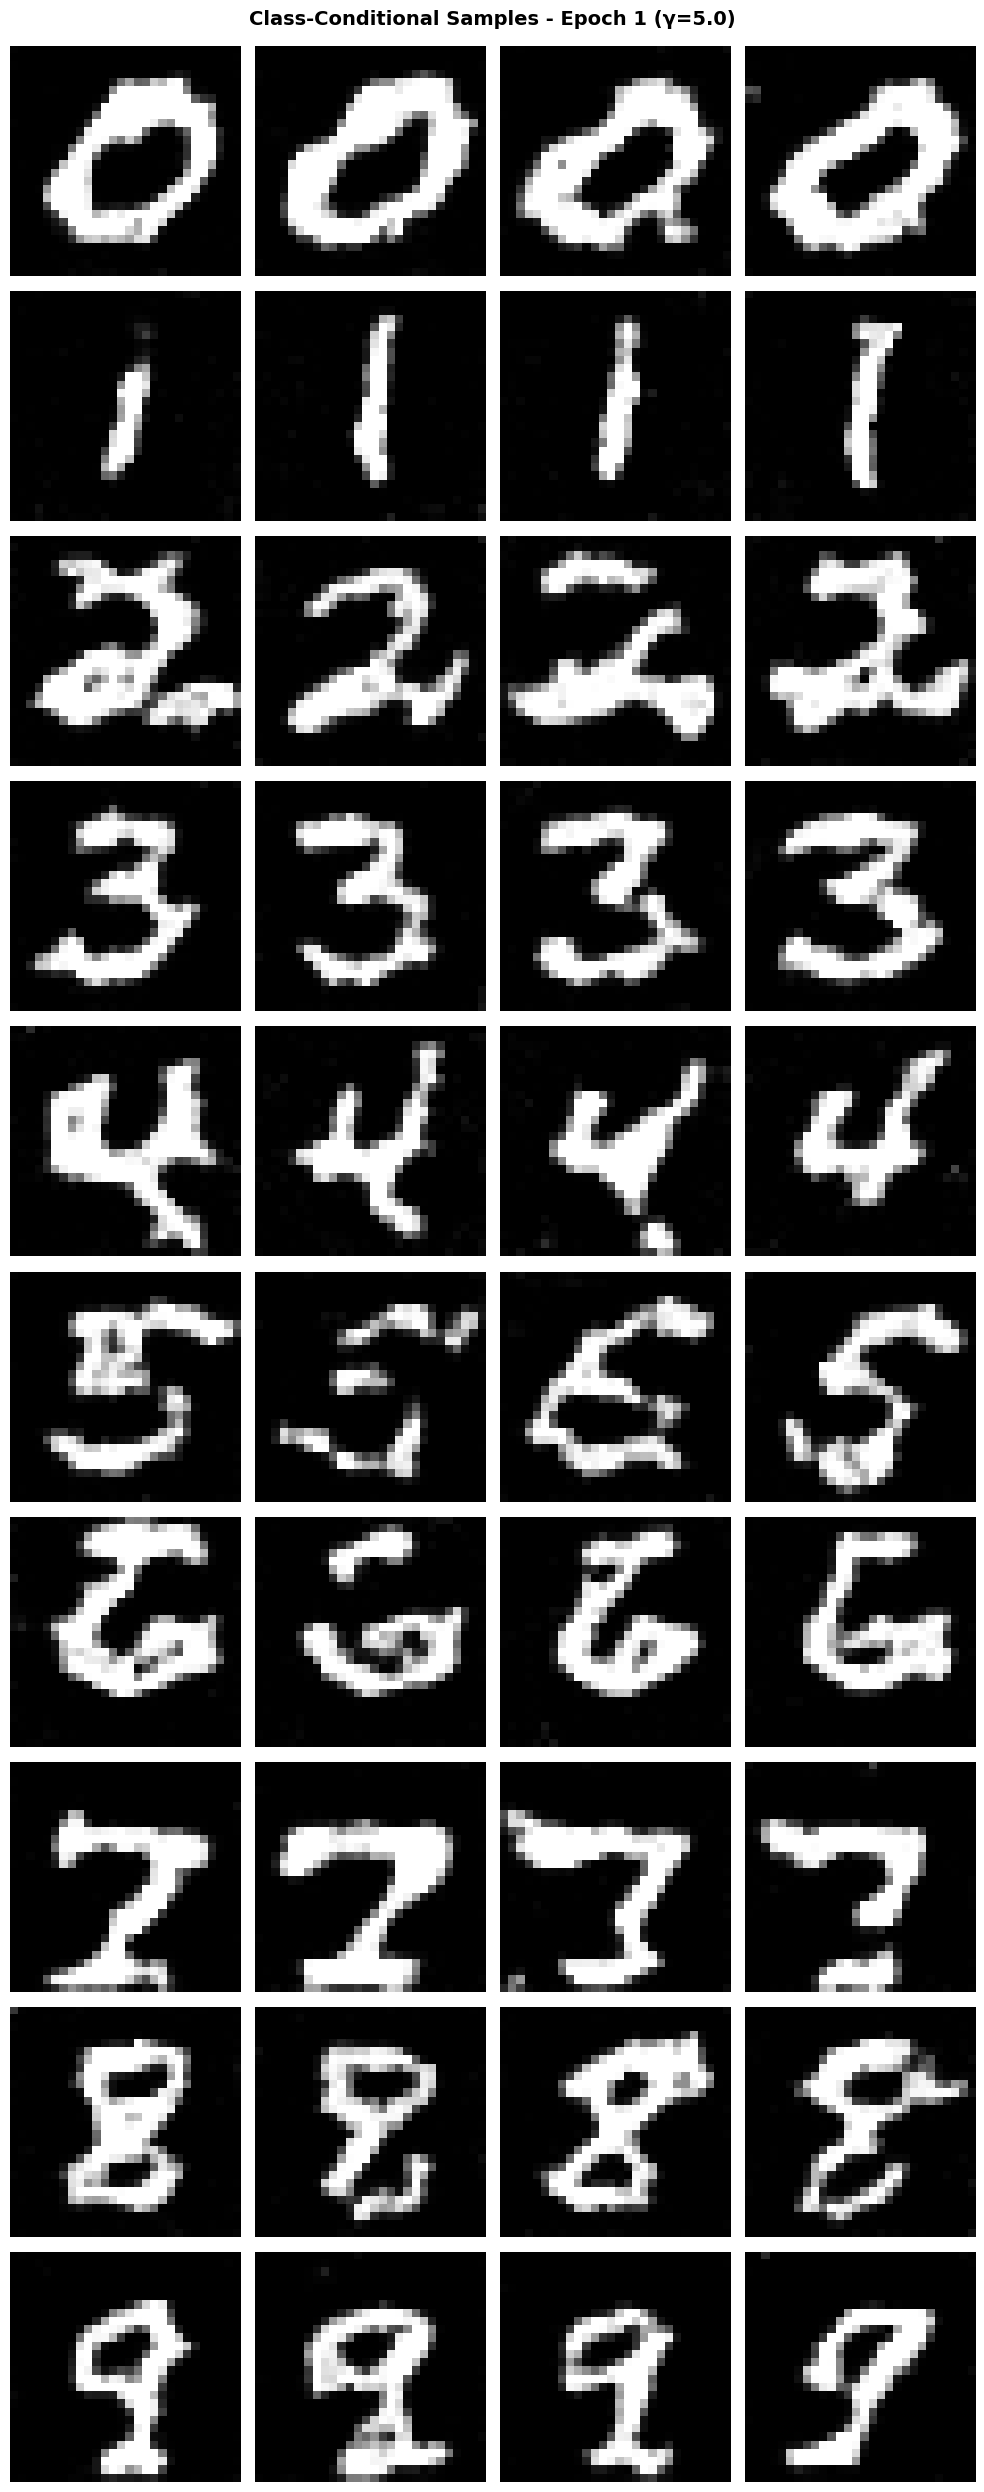


Generating samples from epoch 5 with gamma=5.0
Generating 4 instances of each digit (0-9)...
Saved samples to: class_conditional_samples_with_scheduler/samples_epoch_5_gamma_5.0.png


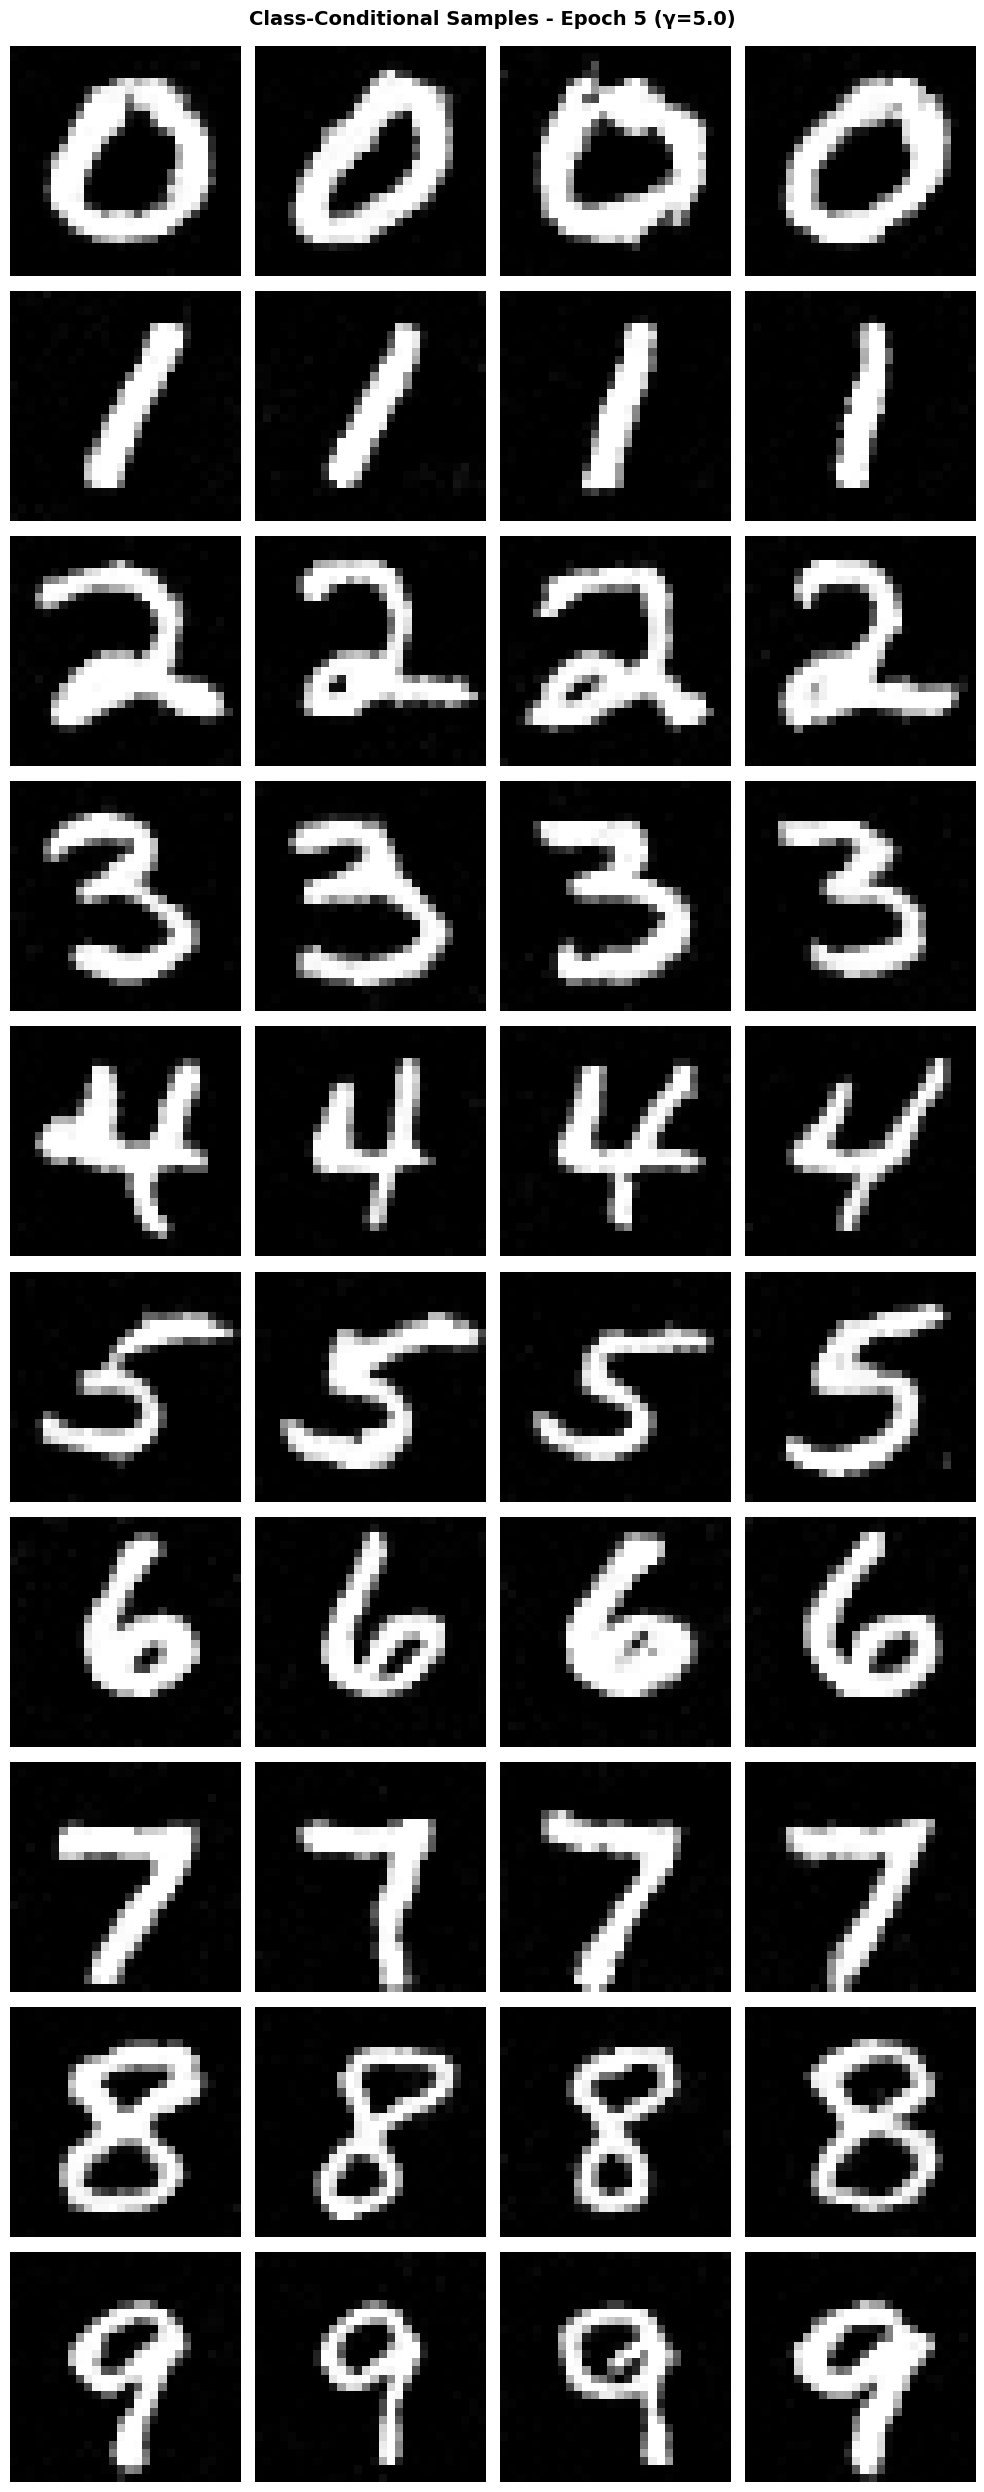


Generating samples from epoch 10 with gamma=5.0
Generating 4 instances of each digit (0-9)...
Saved samples to: class_conditional_samples_with_scheduler/samples_epoch_10_gamma_5.0.png


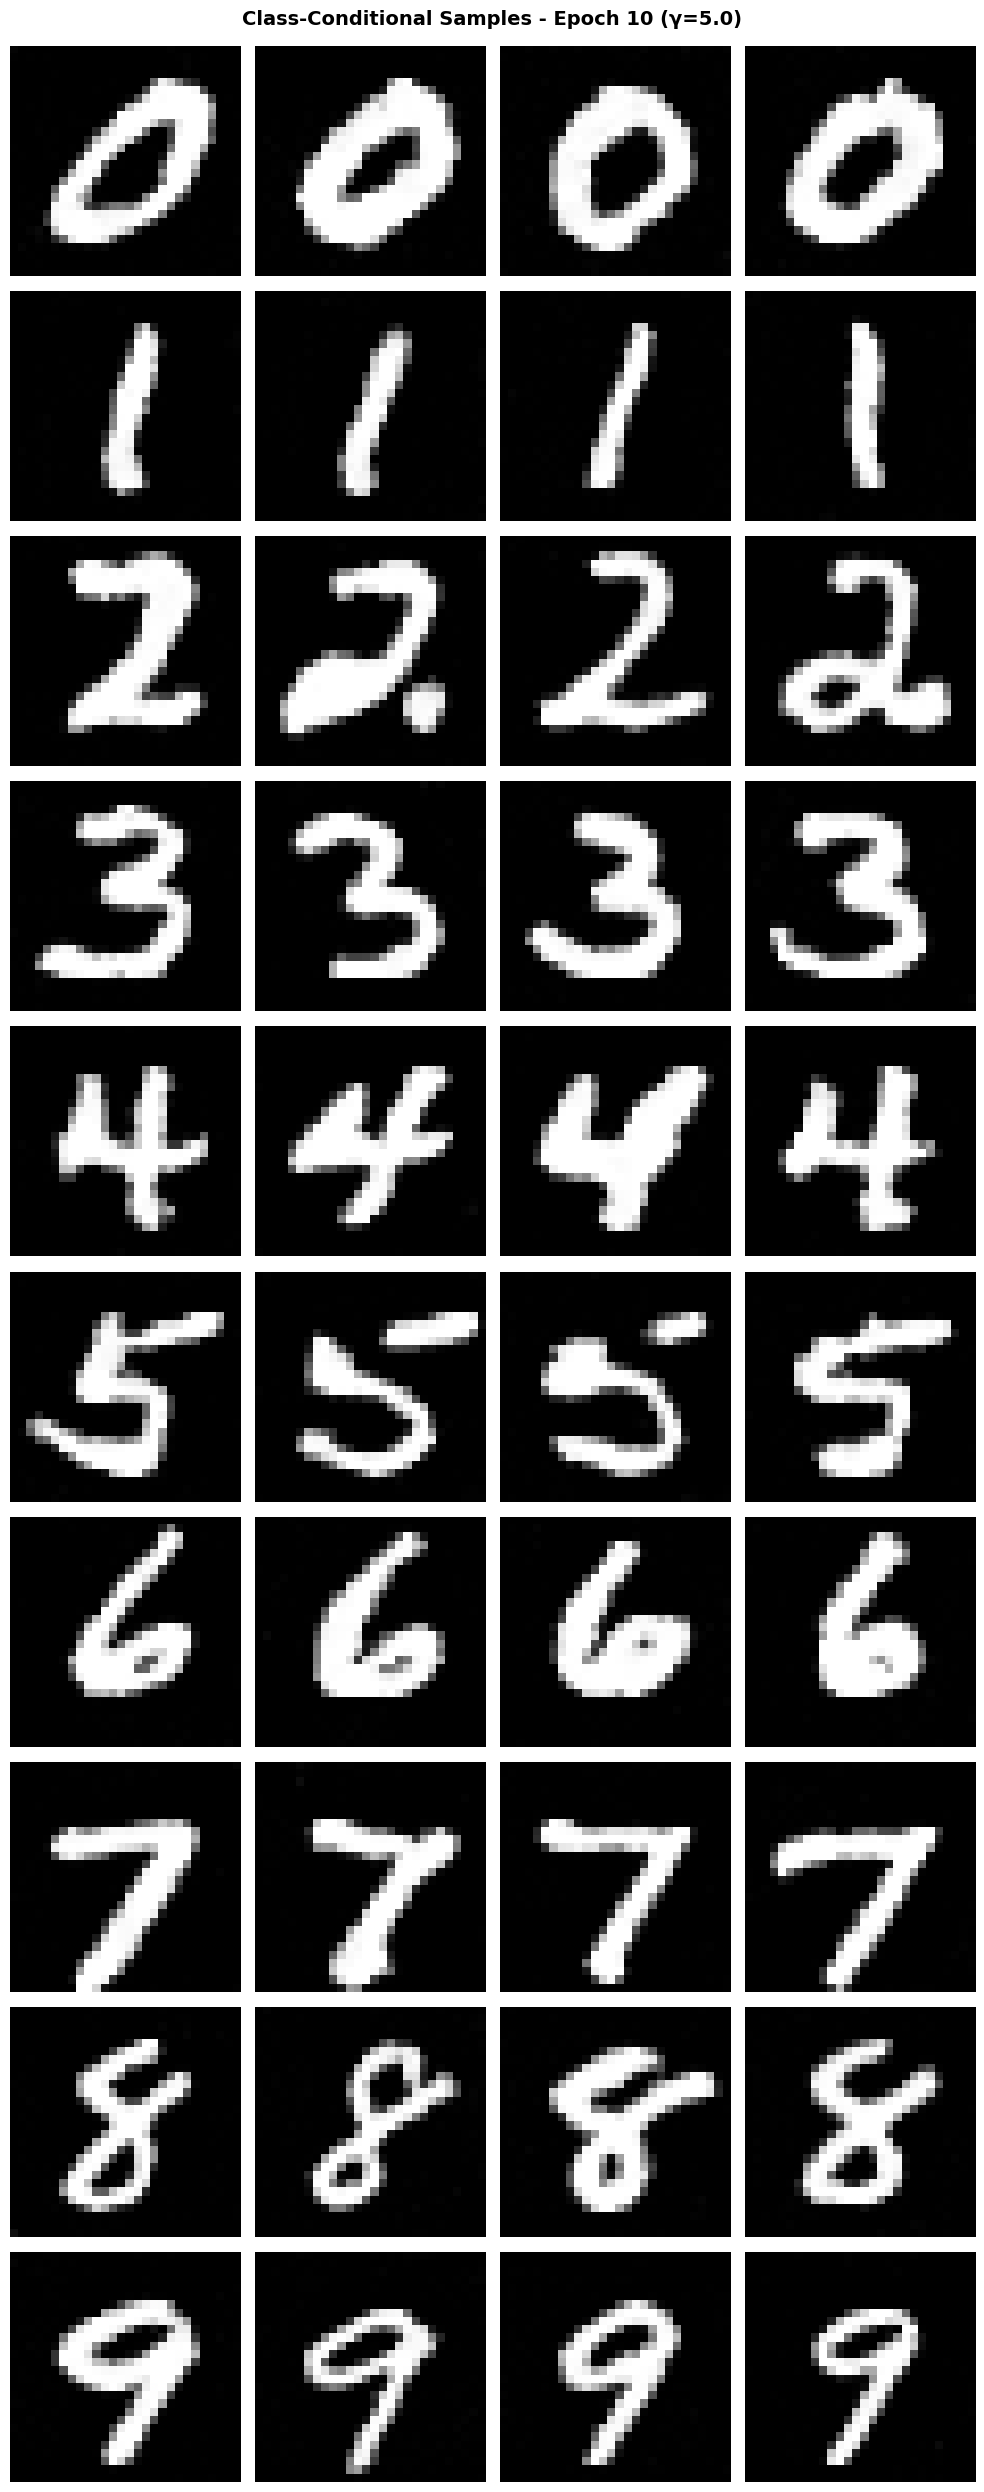


Sampling completed!


In [29]:
# Sampling from the UNet with Class-Conditioning and Classifier-Free Guidance
# Algorithm 4: Class-Conditional Sampling with CFG (gamma = 0.5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
num_hiddens = 64
num_classes = 10
num_ts = 50  # Number of timesteps (T)
guidance_scale = 5.0  # gamma = 0.5 for classifier-free guidance
img_wh = (28, 28)  # MNIST image size
num_samples_per_digit = 4  # 4 instances of each digit
epochs_to_sample = [1, 5, 10]

# Create directory for saving samples
import os
os.makedirs('class_conditional_samples_with_scheduler', exist_ok=True)

@torch.inference_mode()
def class_conditional_sample_algorithm4(
    unet: ClassConditionalUNet,
    c_onehot: torch.Tensor,
    num_ts: int,
    gamma: float,
    seed: int = 0,
) -> torch.Tensor:
    """
    Algorithm 4: Class-Conditional Sampling with Classifier-Free Guidance

    Args:
        unet: ClassConditionalUNet model
        c_onehot: (N, num_classes) one-hot class vector
        num_ts: Number of timesteps T
        gamma: Classifier guidance scale (γ)
        seed: Random seed

    Returns:
        (N, C, H, W) final sample
    """
    unet.eval()
    torch.manual_seed(seed)

    N = c_onehot.shape[0]  # Number of samples
    C = 1  # MNIST: C=1
    H, W = img_wh
    device = next(unet.parameters()).device

    # Line 2: Initialize x_t = x_0 ~ N(0, I)
    x_t = torch.randn(N, C, H, W, device=device)

    # Line 3: For t from 0 to 1, step size 1/T
    dt = 1.0 / num_ts

    for step in range(num_ts):
        # Current time t in [0, 1]
        t = torch.full((N,), step * dt, device=device)  # (N,)

        # Convert one-hot c to class indices for UNet forward
        c_indices = torch.argmax(c_onehot, dim=1)  # (N,)

        # Line 4: u_uncond = u_θ(x_t, t, 0)
        # Create zero one-hot vector for unconditional prediction
        c_zero = torch.zeros_like(c_onehot)  # (N, num_classes) all zeros
        c_zero_indices = torch.zeros(N, dtype=torch.long, device=device)  # (N,)
        # Use mask to drop condition (effectively makes it unconditional)
        mask_uncond = torch.zeros(N, device=device)  # (N,) all zeros
        u_uncond = unet(x_t, c_zero_indices, t, mask=mask_uncond)  # (N, C, H, W)

        # Line 5: u_cond = u_θ(x_t, t, c)
        # Use condition normally (mask=None means keep condition)
        u_cond = unet(x_t, c_indices, t, mask=None)  # (N, C, H, W)

        # Line 6: u = u_uncond + γ(u_cond - u_uncond)  (Classifier-free guidance)
        u = u_uncond + gamma * (u_cond - u_uncond)  # (N, C, H, W)

        # Line 7: x_t = x_t + (1/T)u
        x_t = x_t + dt * u  # (N, C, H, W)

    # Line 9: return x_t
    return x_t

# Generate samples for each epoch
for epoch in epochs_to_sample:
    print(f'\n{"="*60}')
    print(f'Generating samples from epoch {epoch} with gamma={guidance_scale}')
    print(f'{"="*60}')

    # Load checkpoint
    checkpoint_path = f'checkpoint_class_conditional_epoch_{epoch}_with_scheduler.pth'

    if not os.path.exists(checkpoint_path):
        print(f'Warning: Checkpoint {checkpoint_path} not found.')
        print('Make sure you have trained the model and saved checkpoints at epochs 1, 5, and 10.')
        continue

    # Load model
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Recreate model architecture
    unet = ClassConditionalUNet(
        in_channels=1,
        num_classes=checkpoint['num_classes'],
        num_hiddens=checkpoint['num_hiddens']
    ).to(device)

    # Load state dict
    unet.load_state_dict(checkpoint['unet_state_dict'])
    unet.eval()

    # Generate 4 instances of each digit (0-9)
    all_samples = []
    all_labels = []

    print(f'Generating {num_samples_per_digit} instances of each digit (0-9)...')

    for digit in range(num_classes):
        # Create one-hot vector for this digit
        # We'll generate num_samples_per_digit samples for each digit
        c_onehot = torch.zeros(num_samples_per_digit, num_classes, device=device)
        c_onehot[:, digit] = 1.0  # (num_samples_per_digit, num_classes)

        # Generate samples for this digit
        for sample_idx in range(num_samples_per_digit):
            # Use different seed for each sample
            seed = epoch * 1000 + digit * 10 + sample_idx

            # Get single sample (one-hot vector for one sample)
            c_onehot_single = c_onehot[sample_idx:sample_idx+1]  # (1, num_classes)

            # Generate sample using Algorithm 4
            sample = class_conditional_sample_algorithm4(
                unet=unet,
                c_onehot=c_onehot_single,
                num_ts=checkpoint['num_ts'],
                gamma=guidance_scale,
                seed=seed
            )

            all_samples.append(sample.cpu())
            all_labels.append(digit)

    # Stack all samples: (num_classes * num_samples_per_digit, 1, 28, 28)
    samples_tensor = torch.cat(all_samples, dim=0)

    # Clamp values to [0, 1] for visualization
    samples_tensor = torch.clamp(samples_tensor, 0, 1)

    # Visualize samples: 10 rows (one per digit), 4 columns (4 instances)
    fig, axes = plt.subplots(num_classes, num_samples_per_digit, figsize=(10, 25))

    for digit in range(num_classes):
        for sample_idx in range(num_samples_per_digit):
            idx = digit * num_samples_per_digit + sample_idx
            axes[digit, sample_idx].imshow(samples_tensor[idx].squeeze(), cmap='gray')
            if sample_idx == 0:
                axes[digit, sample_idx].set_ylabel(f'Digit {digit}', fontsize=12, fontweight='bold')
            axes[digit, sample_idx].axis('off')

    plt.suptitle(f'Class-Conditional Samples - Epoch {epoch} (γ={guidance_scale})',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()

    # Save figure
    save_path = f'class_conditional_samples_with_scheduler/samples_epoch_{epoch}_gamma_{guidance_scale}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved samples to: {save_path}')
    plt.show()

print(f'\n{"="*60}')
print('Sampling completed!')
print(f'{"="*60}')
